<a href="https://colab.research.google.com/github/FatemehNMT/Visual-SLAM-Book-Google-Colab/blob/main/MySLAM_Chapter_12_Practice_Stereo_Visual_Odometry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Summery: Main Concepts**

1. Lie Groupe and Algebra
3D Rigid Body Motion -->> SE(3)(Combination of R and T)
2. Ceres vs. g2o
g2o is based on graph-optimization: Nodes = states (camera poses in SLAM) and Edges = constraints (observations in SLAM)
3. Bundle Adjustment (BA)
Simultaniously optimisation of camera poses and landmarks (backend in SLAM).
4. Epipolar Geometry (In SLAM: To calculate the correspondence between two frames and estimate the initial motion)
5. PnP (Perspective-n-Point)
When you already have a map (3D points), you use PnP to estimate the pose of the new frame.
6. Visual Odometry (VO)
front-end: Estimate the camera path in real time, before final correction with BA.
7. Solve a BA problem with g2o
Poses, landmarks and edges (reprojection error) optimisation.
8. Pose Graph Optimization with g2o
Poses optimisation.
9. Map-based Localization

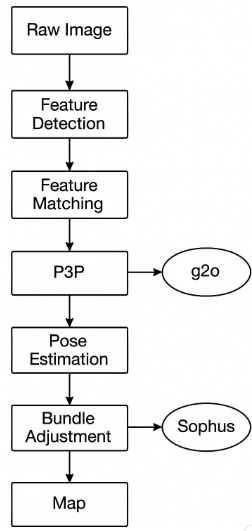

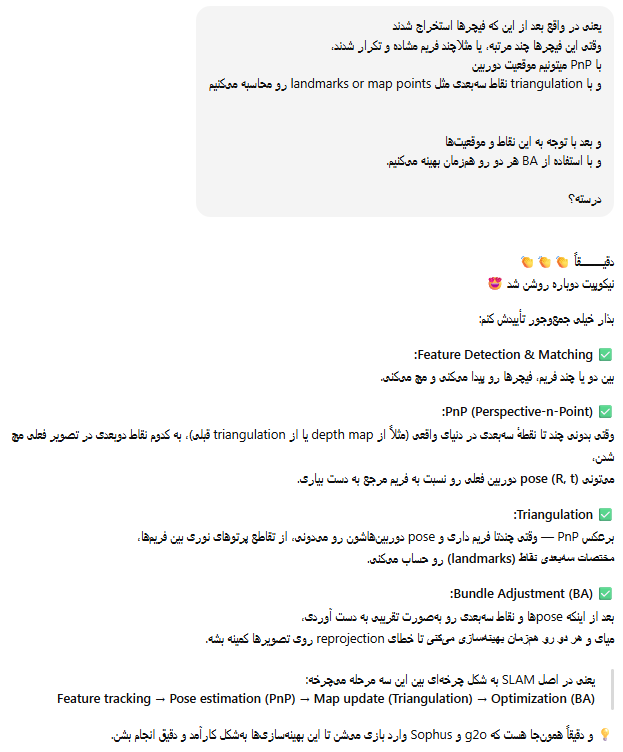

**Feature Detection & Matching** within 2 or more frames --> \
**PnP (Perspective-n-Point):** There are points found in 3D world applying **depth map** or **triangulation**\
**Triangulation: **When we have a couple of frames, with their known

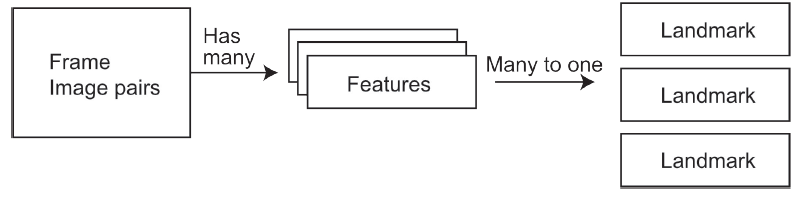

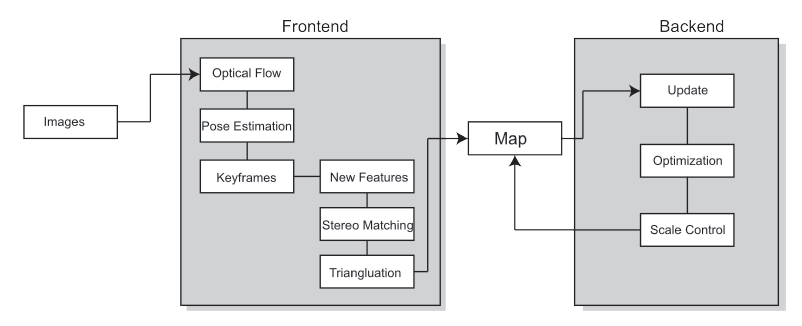

# **SLAM Essentials Map — Part I**

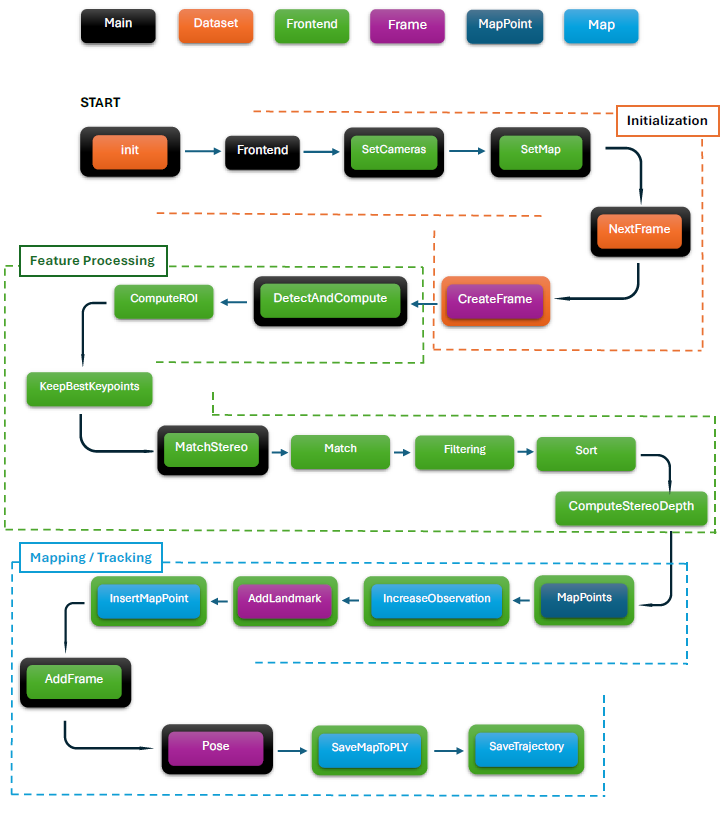

**SLAM Frontend & Initialization Flow _ Part I**:\
This flowchart uses colors to represent different parts of the codebase.
The **background color** indicates where each function or module is *declared*, while the **foreground color** shows where it is used or *called* in the pipeline.\
Dashed boundaries divide the SLAM system into its major stages: **Initialization**, **Feature Processing**, and **Mapping / Tracking**.

A short **summery** of what we have done up to here is presented in the following.

In [ ]:
main → Dataset.Init
     → load frames
     → Frontend.AddFrame
          → detect
          → match
          → depth
          → triangulate
          → map insert
     → save map & trajectory


**Start:**

In [ ]:
main()

**Input:**

In [ ]:
dataset_path = argv[1]

**Dataset Preparation:**

In [ ]:
Dataset::Ptr ds(new Dataset(dataset_path));

**Init()**

In [ ]:
ds->Init()
    ├─ چک فولدر image_0
    ├─ چک فولدر image_1
    ├─ ذخیره مسیرها
    └─ آماده‌سازی برای خواندن تصاویر

**Frontend**

In [ ]:
Frontend::Ptr frontend(new Frontend(...));
frontend->SetCameras(cam_left, cam_right);
frontend->SetMap(map);

**Main Loop**

In [ ]:
for frame_id in frames:
    Frame::Ptr frame(new Frame());
    ds->NextFrame(frame);  //← بارگذاری تصویر L و R
    frontend->AddFrame(frame);

**Frontend::AddFrame()**

In [ ]:
AddFrame(frame):
    ├─ DetectAndCompute(frame)
    │      ├─ ROI
    │      ├─ ORB detect
    │      ├─ ORB descriptors
    │      └─ بهترین keypoint‌ها
    │
    ├─ MatchStereo(frame, matches)
    │      ├─ BFMatcher raw match
    │      ├─ epipolar filtering
    │      ├─ sort by distance
    │      └─ resize to N matches
    │
    ├─ ComputeStereoDepth()
    │      ├─ disparity = xL - xR
    │      ├─ Z = fx * B / disp
    │      ├─ X = (u - cx) * Z / fx
    │      └─ Y = (v - cy) * Z / fy
    │
    ├─ ساخت MapPoint برای هر نقطه
    │      ├─ mp = new MapPoint()
    │      ├─ mp->IncreaseObservation()
    │      ├─ frame->AddLandmark(mp)
    │      └─ map_->InsertMapPoint(mp)
    │
    └─ map_->InsertKeyFrame(frame)


**Track**

In [ ]:
Track(new_frame):
    ├─ match new_frame with last_frame
    ├─ findEssentialMat()
    ├─ recoverPose()
    ├─ SE3 concatenation
    ├─ last_frame = new_frame
    └─ return success


**Map**

In [ ]:
InsertKeyFrame(frame):
    keyframes_[id] = frame

InsertMapPoint(mp):
    map_points_[id] = mp

AddFrame(frame):
    all_frames_.push_back(frame)


**Save Results**

In [ ]:
Map::SaveMapToPLY("map_xxx.ply")
Map::SaveTrajectory("trajectory.txt")
main.cpp → directly saving trajectory from all_frames_


# **Mount**

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


# **Installation**

**Eigen**

In [ ]:
!sudo apt-get update
!sudo apt-get install -y cmake build-essential \
    libeigen3-dev libsuitesparse-dev libcholmod3 \
    freeglut3-dev libglew-dev

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,149 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Pa

**OpenCV**

In [ ]:
!sudo apt update
!sudo apt install libopencv-dev

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:7 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (3,284 B/s)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
41 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of

Find its path and add it to the CMakeList.

In [ ]:
!dpkg -L libopencv-dev | grep OpenCVConfig.cmake

# Add it to CMake, just before find_package(OpenCV REQUIRED): set(OpenCV_DIR /usr/lib/x86_64-linux-gnu/cmake/opencv4)

/usr/lib/x86_64-linux-gnu/cmake/opencv4/OpenCVConfig.cmake


**Open3D**

In [ ]:
!pip install open3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.8 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


**Sophus**

In [ ]:
!pwd

/content


In [ ]:
!sudo apt update
!sudo apt install -y cmake libeigen3-dev

!git clone https://github.com/strasdat/Sophus.git
%cd Sophus

!mkdir build
%cd build

!cmake .. -DCMAKE_BUILD_TYPE=Release
!make -j4
!sudo make install

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (2,757 B/s)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
41 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of

# **Prepare Documents and Generate Folders**

In [ ]:
!pwd
!ls

/content/Sophus/build
app		     config		   SophusConfig.cmake
CMakeCache.txt	     CTestTestfile.cmake   SophusConfigVersion.cmake
CMakeFiles	     include		   SophusTargets.cmake
cmake_install.cmake  install_manifest.txt  src
cmake_modules	     Makefile		   test


In [ ]:
%cd /content/

/content


In [ ]:
!mkdir MySLAM_Ch13

In [ ]:
%cd /content/MySLAM_Ch13

/content/MySLAM_Ch13


In [ ]:
!pwd

/content/MySLAM_Ch13


In [ ]:
!mkdir app
!mkdir cmake_modules
!mkdir -p include/myslam
!mkdir test
!mkdir src
!mkdir config

# **Step 1: Data Preparation**

## **Headers**

**common_include.h**\
Aggregate all includes in a file to have a clean and easy to read code.

In [ ]:
%cd /content/MySLAM_Ch13/include/myslam

/content/MySLAM_Ch13/include/myslam


In [ ]:
%%writefile common_include.h
// include/myslam/common_include.h
#ifndef MYSLAM_COMMON_INCLUDE_H
#define MYSLAM_COMMON_INCLUDE_H

// C++
#include <iostream>
#include <memory>
#include <vector>
#include <string>
#include <mutex>
#include <filesystem> // C++17

// Eigen
#include <Eigen/Dense>

// OpenCV
#include <opencv2/opencv.hpp>
#endif // MYSLAM_COMMON_INCLUDE_H


Overwriting common_include.h


In [ ]:
%%writefile frame.h

// include/myslam/frame.h
#pragma once
#include "common_include.h"

namespace myslam {

struct Frame {
    typedef std::shared_ptr<Frame> Ptr;  // Now we can use FramePtr instead of Frame* یعنی Frame::Ptr همون std::shared_ptr<Frame>ـه
    int id = -1;
    cv::Mat left_img, right_img;

    static Frame::Ptr CreateFrame() {
        static long factory_id = 0;
        Frame::Ptr f(new Frame);
        f->id = factory_id++;
        return f;
    }
};

}  // namespace myslam

Writing frame.h


In [ ]:
%%writefile dataset.h

// include/myslam/dataset.h
#ifndef MYSLAM_DATASET_H
#define MYSLAM_DATASET_H

#pragma once

#include "myslam/common_include.h"
#include "myslam/frame.h"

// Forward declaration of Frame to avoid heavy include here.
// Frame will be defined later in a separate file.

namespace myslam {
// struct Frame;
// typedef std::shared_ptr<Frame> FramePtr;

class Dataset {
public:
    EIGEN_MAKE_ALIGNED_OPERATOR_NEW;
    typedef std::shared_ptr<Dataset> Ptr;
    typedef Frame::Ptr FramePtr;  // Now we can use FramePtr instead of Frame*

    Dataset(const std::string& dataset_path);

    // Read the dataset's information (paths, calibration, ...)
    bool Init();

    // Next freme, and return nullptr if finished.
    FramePtr NextFrame();

    int ImageCount() const { return static_cast<int>(left_images_.size()); }

private:
    std::string dataset_path_;
    int current_image_index_ = 0;

    // List the path to images right/left
    std::vector<std::string> left_images_;
    std::vector<std::string> right_images_;
};

} // namespace myslam

#endif // MYSLAM_DATASET_H


Overwriting dataset.h


## **cpp**

In [ ]:
%cd /content/MySLAM_Ch13/src

/content/MySLAM_Ch13/src


### **dataset.cpp**

In [ ]:
%%writefile dataset.cpp

// src/dataset.cpp
#include "myslam/dataset.h"
#include "myslam/common_include.h"
#include "myslam/frame.h"

namespace myslam {

Dataset::Dataset(const std::string& dataset_path) : dataset_path_(dataset_path) {}

bool Dataset::Init() {
    namespace fs = std::filesystem;
    std::string left_dir = dataset_path_ + "/image_0";
    std::string right_dir = dataset_path_ + "/image_1";

    if (!fs::exists(left_dir) || !fs::exists(right_dir)) {
        std::cerr << "Dataset folders not found: " << left_dir << " or " << right_dir << std::endl;
        return false;
    }

    left_images_.clear();
    right_images_.clear();

    for (auto &p : fs::directory_iterator(left_dir)) left_images_.push_back(p.path().string());
    for (auto &p : fs::directory_iterator(right_dir)) right_images_.push_back(p.path().string());

    std::sort(left_images_.begin(), left_images_.end());
    std::sort(right_images_.begin(), right_images_.end());

    if (left_images_.size() != right_images_.size()) {
        std::cerr << "Left and right image counts differ!" << std::endl;
        size_t n = std::min(left_images_.size(), right_images_.size());
        left_images_.resize(n);
        right_images_.resize(n);
    }

    std::cout << "Dataset init: found " << left_images_.size() << " stereo pairs.\n";
    return true;
}

Dataset::FramePtr Dataset::NextFrame() {
    if (current_image_index_ >= static_cast<int>(left_images_.size())) return nullptr;

    cv::Mat left = cv::imread(left_images_[current_image_index_], cv::IMREAD_GRAYSCALE);
    cv::Mat right = cv::imread(right_images_[current_image_index_], cv::IMREAD_GRAYSCALE);

    if (left.empty() || right.empty()) {
        std::cerr << "Failed to read images at index " << current_image_index_ << std::endl;
        return nullptr;
    }

    Frame::Ptr f = Frame::CreateFrame();
    f->left_img = left;
    f->right_img = right;

    current_image_index_++;
    return f;
}

} // namespace myslam


Overwriting dataset.cpp


### **main.cpp**

In [ ]:
%%writefile main.cpp

// src/main.cpp
#include "myslam/common_include.h"
#include "myslam/dataset.h"
#include "myslam/frame.h"
#include <chrono>
#include <thread>

using namespace myslam;

int main(int argc, char** argv) {
    if (argc != 2) {
        std::cout << "Usage: run_dataset <dataset_directory>" << std::endl;
        return -1;
    }

    std::string dataset_path = argv[1];
    Dataset::Ptr ds(new Dataset(dataset_path));
    if (!ds->Init()) {
        std::cerr << "Dataset init failed!" << std::endl;
        return -1;
    }

    std::cout << "Total frames: " << ds->ImageCount() << std::endl;

    while (true) {
        auto frame = ds->NextFrame();
        if (!frame) break;

        // It is useless, as we are applying colab notebook.
        // cv::imshow("left", frame->left_img);
        // cv::imshow("right", frame->right_img);

        cv::imwrite("left.png", frame->left_img);
        cv::imwrite("right.png", frame->right_img);

        int key = cv::waitKey(30);
        if (key == 27) break; // ESC
    }

    std::cout << "All frames processed." << std::endl;
    return 0;
}


Writing main.cpp


## **RUN**

In [ ]:
%cd /content/MySLAM_Ch13

/content/MySLAM_Ch13


**CMakeLists.txt**

In [ ]:
%%writefile CMakeLists.txt
cmake_minimum_required(VERSION 3.10)
project(ch13_minimal)

set(CMAKE_CXX_STANDARD 17)
set(CMAKE_BUILD_TYPE Release)

set(OpenCV_DIR /usr/lib/x86_64-linux-gnu/cmake/opencv4)

find_package(OpenCV REQUIRED)
find_package(Eigen3 REQUIRED)

include_directories(${OpenCV_INCLUDE_DIRS} ${EIGEN3_INCLUDE_DIR})
include_directories(${CMAKE_SOURCE_DIR}/include)

add_executable(run_dataset
    src/main.cpp
    src/dataset.cpp
)

target_link_libraries(run_dataset ${OpenCV_LIBS})


Writing CMakeLists.txt


In [ ]:
!rm -r build

rm: cannot remove 'build': No such file or directory


In [ ]:
!mkdir build
%cd build

!cmake ..

!make

/content/MySLAM_Ch13/build
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Found OpenCV: /usr (found version "4.5.4")
-- Configuring done (0.9s)
-- Generating done (0.0s)
-- Build files have been written to: /content/MySLAM_Ch13/build
[ 33%] Building CXX object CMakeFiles/run_dataset.dir/src/main.cpp.o
[ 66%] Building CXX object CMakeFiles/run_dataset.dir/src/dataset.cpp.o
[100%] Linking CXX executable run_dataset
[100%] Built target run_dataset


In [ ]:
!./run_dataset /content/gdrive/MyDrive/KITTI_Dataset/05

Dataset init: found 301 stereo pairs.
Total frames: 301
^C


# **Step 2: Feature Extraction**

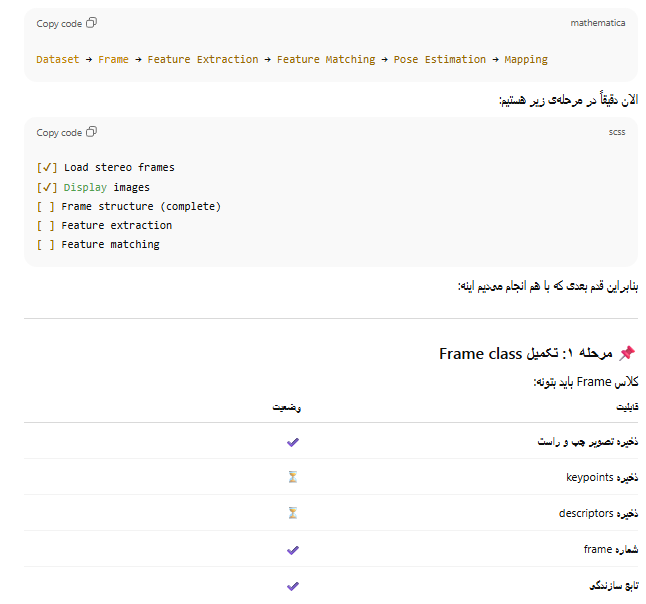

## **Headers**

In [ ]:
%cd /content/MySLAM_Ch13/include/myslam

/content/MySLAM_Ch13/include/myslam


In [ ]:
%%writefile frame.h

// include/myslam/frame.h
#pragma once
#include "common_include.h"

namespace myslam {

struct Frame {
    typedef std::shared_ptr<Frame> Ptr;
    long unsigned int id;
    cv::Mat left_img, right_img;

    // New fields
    std::vector<cv::KeyPoint> keypoints_left, keypoints_right;
    cv::Mat descriptors_left, descriptors_right;

    static Frame::Ptr CreateFrame();

    Frame() {}

    // Feature extraction
    void ExtractFeatures();
};

}  // namespace myslam


Overwriting frame.h


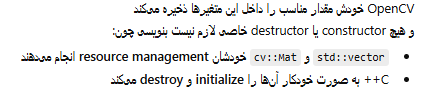

## **cpp**

In [ ]:
%cd /content/MySLAM_Ch13/src

/content/MySLAM_Ch13/src


In [ ]:
%%writefile frame.cpp

#include "myslam/frame.h"

namespace myslam {

static long unsigned int global_frame_id = 0;

Frame::Ptr Frame::CreateFrame() {
    Frame::Ptr new_frame(new Frame());
    new_frame->id = global_frame_id++;
    return new_frame;
}

void Frame::ExtractFeatures() {
    cv::Ptr<cv::Feature2D> orb = cv::ORB::create(200); // تعداد featureها: بعداً تنظیم می‌کنیم

    // استخراج از تصویر چپ
    orb->detectAndCompute(left_img, cv::Mat(), keypoints_left, descriptors_left);

    // اگر stereo داریم → از تصویر راست نیز استخراج می‌کنیم
    if (!right_img.empty()) {
        orb->detectAndCompute(right_img, cv::Mat(), keypoints_right, descriptors_right);
    }
}


}


Overwriting frame.cpp


### **main.cpp**

In [ ]:
%%writefile main.cpp

// src/main.cpp
#include "myslam/common_include.h"
#include "myslam/dataset.h"
#include "myslam/frame.h"
#include <chrono>
#include <thread>

using namespace myslam;

int main(int argc, char** argv) {
    if (argc != 2) {
        std::cout << "Usage: run_dataset <dataset_directory>" << std::endl;
        return -1;
    }

    std::string dataset_path = argv[1];
    Dataset::Ptr ds(new Dataset(dataset_path));
    if (!ds->Init()) {
        std::cerr << "Dataset init failed!" << std::endl;
        return -1;
    }

    std::cout << "Total frames: " << ds->ImageCount() << std::endl;

    while (true) {
        auto frame = ds->NextFrame();
        if (!frame) break;

        // cv::imshow("left", frame->left_img);
        // cv::imshow("right", frame->right_img);

        if (frame->left_img.empty()) {
        std::cout << "Cannot load image!" << std::endl;
        return -1;
        }

        std::cout << "Frame ID: " << frame->id << std::endl;

        frame->ExtractFeatures();

        std::cout << "Extracted keypoints: " << frame->keypoints_left.size() << std::endl;
        std::cout << "Descriptor size: " << frame->descriptors_left.rows << " x "
                  << frame->descriptors_left.cols << std::endl;


        // نمایش برای تست
        cv::Mat vis;
        cv::drawKeypoints(frame->left_img, frame->keypoints_left, vis, cv::Scalar(0,255,0));
        // cv::imshow("Features", vis);
        cv::imwrite("Features.png", vis);
        cv::waitKey(0);


        cv::imwrite("left.png", frame->left_img);
        cv::imwrite("right.png", frame->right_img);

        int key = cv::waitKey(30);
        if (key == 27) break; // ESC
    }

    std::cout << "All frames processed." << std::endl;
    return 0;
}


Overwriting main.cpp


In [ ]:
%cd /content/MySLAM_Ch13

/content/MySLAM_Ch13


In [ ]:
%%writefile CMakeLists.txt
cmake_minimum_required(VERSION 3.10)
project(ch13_minimal)

set(CMAKE_CXX_STANDARD 17)
set(CMAKE_BUILD_TYPE Release)

set(OpenCV_DIR /usr/lib/x86_64-linux-gnu/cmake/opencv4)

find_package(OpenCV REQUIRED)
find_package(Eigen3 REQUIRED)

include_directories(${OpenCV_INCLUDE_DIRS} ${EIGEN3_INCLUDE_DIR})
include_directories(${CMAKE_SOURCE_DIR}/include)

add_executable(run_dataset
    src/main.cpp
    src/frame.cpp
    src/dataset.cpp
)

target_link_libraries(run_dataset ${OpenCV_LIBS})


Overwriting CMakeLists.txt


## **RUN**

In [ ]:
%cd /content/MySLAM_Ch13

/content/MySLAM_Ch13


In [ ]:
!rm -r build

In [ ]:
!mkdir build
%cd build

!cmake ..

!make

/content/MySLAM_Ch13/build
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Found OpenCV: /usr (found version "4.5.4")
-- Configuring done (0.4s)
-- Generating done (0.0s)
-- Build files have been written to: /content/MySLAM_Ch13/build
[ 25%] Building CXX object CMakeFiles/run_dataset.dir/src/main.cpp.o
[ 50%] Building CXX object CMakeFiles/run_dataset.dir/src/frame.cpp.o
[ 75%] Building CXX object CMakeFiles/run_dataset.dir/src/dataset.cpp.o
[100%] Linking CXX executable run_dataset
[100%] Built target run_dataset


In [ ]:
!./run_dataset /content/gdrive/MyDrive/KITTI_Dataset/05

Dataset init: found 301 stereo pairs.
Total frames: 301
Frame ID: 0
Extracted keypoints: 200
Descriptor size: 200 x 32
Frame ID: 1
Extracted keypoints: 200
Descriptor size: 200 x 32
^C


# **Step 3: Feature Matching**

## **Headers**

In [ ]:
%cd /content/MySLAM_Ch13/include/myslam

/content/MySLAM_Ch13/include/myslam


In [ ]:
%%writefile frame.h

// include/myslam/frame.h
#pragma once
#include "common_include.h"

namespace myslam {

struct Frame {
    typedef std::shared_ptr<Frame> Ptr;
    long unsigned int id;
    cv::Mat left_img, right_img;

    // New fields
    std::vector<cv::KeyPoint> keypoints_left, keypoints_right;
    cv::Mat descriptors_left, descriptors_right;

    static Frame::Ptr CreateFrame();

    Frame() {}

    // Feature extraction
    void ExtractFeatures();

    // Feature matcing
    void MatchFeaturesStereo(std::vector<cv::DMatch> &matches);

};

}  // namespace myslam


Overwriting frame.h


## **cpp**

In [ ]:
%cd /content/MySLAM_Ch13/src

/content/MySLAM_Ch13/src


In [ ]:
%%writefile frame.cpp

#include "myslam/frame.h"

namespace myslam {

static long unsigned int global_frame_id = 0;

Frame::Ptr Frame::CreateFrame() {
    Frame::Ptr new_frame(new Frame());
    new_frame->id = global_frame_id++;
    return new_frame;
}

void Frame::ExtractFeatures() {
    cv::Ptr<cv::Feature2D> orb = cv::ORB::create(200); // تعداد featureها: بعداً تنظیم می‌کنیم

    // استخراج از تصویر چپ
    orb->detectAndCompute(left_img, cv::Mat(), keypoints_left, descriptors_left);

    // اگر stereo داریم → از تصویر راست نیز استخراج می‌کنیم
    if (!right_img.empty()) {
        orb->detectAndCompute(right_img, cv::Mat(), keypoints_right, descriptors_right);
    }
}

void Frame::MatchFeaturesStereo(std::vector<cv::DMatch>& matches) {
    if (descriptors_left.empty() || descriptors_right.empty()) return;

    cv::BFMatcher matcher(cv::NORM_HAMMING, true); // crossCheck = true
    matcher.match(descriptors_left, descriptors_right, matches);

    // Sort matches based on distance (quality)
    std::sort(matches.begin(), matches.end(), [](const cv::DMatch& m1, const cv::DMatch& m2){
        return m1.distance < m2.distance;
    });
}


}


Overwriting frame.cpp


### **main.cpp**

In [ ]:
%%writefile main.cpp

// src/main.cpp
#include "myslam/common_include.h"
#include "myslam/dataset.h"
#include "myslam/frame.h"
#include <chrono>
#include <thread>

using namespace myslam;

int main(int argc, char** argv) {
    if (argc != 2) {
        std::cout << "Usage: run_dataset <dataset_directory>" << std::endl;
        return -1;
    }

    std::string dataset_path = argv[1];
    Dataset::Ptr ds(new Dataset(dataset_path));
    if (!ds->Init()) {
        std::cerr << "Dataset init failed!" << std::endl;
        return -1;
    }

    std::cout << "Total frames: " << ds->ImageCount() << std::endl;

    while (true) {
        auto frame = ds->NextFrame();
        if (!frame) break;

        if (frame->left_img.empty() || frame->right_img.empty()) {
            std::cout << "Error reading images!" << std::endl;
            return -1;
        }

        // cv::imshow("left", frame->left_img);
        // cv::imshow("right", frame->right_img);

        if (frame->left_img.empty()) {
        std::cout << "Cannot load image!" << std::endl;
        return -1;
        }

        std::cout << "Frame ID: " << frame->id << std::endl;

        frame->ExtractFeatures();

        std::cout << "Extracted keypoints: " << frame->keypoints_left.size() << std::endl;
        std::cout << "Descriptor size: " << frame->descriptors_left.rows << " x "
                  << frame->descriptors_left.cols << std::endl;
        // نمایش برای تست
        cv::Mat vis;
        cv::drawKeypoints(frame->left_img, frame->keypoints_left, vis, cv::Scalar(0,255,0));
        // cv::imshow("Features", vis);
        cv::imwrite("Features.png", vis);
        cv::waitKey(0);


        // Feature Matching
        std::vector<cv::DMatch> matches;
        frame->MatchFeaturesStereo(matches);
        std::cout << "Found matches: " << matches.size() << std::endl;
        // نمایش برای تست
        // Visualization
        cv::Mat viss;
        cv::drawMatches(frame->left_img, frame->keypoints_left,
                        frame->right_img, frame->keypoints_right,
                        matches, viss);
        //cv::imshow("Stereo Matches", viss);
        cv::imwrite("Stereo Matches.png", viss);
        cv::waitKey(0);


        cv::imwrite("left.png", frame->left_img);
        cv::imwrite("right.png", frame->right_img);
        //cv::imwrite("left_" + std::to_string(frame->id) + ".png", frame->left_img);
        //cv::imwrite("right_" + std::to_string(frame->id) + ".png", frame->left_img);


        int key = cv::waitKey(0);
        if (key == 27) break; // ESC
    }

    std::cout << "All frames processed." << std::endl;
    return 0;
}


Overwriting main.cpp


**for debug**

### **main.cpp**

In [ ]:
%%writefile main.cpp

// src/main.cpp
#include "myslam/common_include.h"
#include "myslam/dataset.h"
#include "myslam/frame.h"
#include <chrono>
#include <thread>

using namespace myslam;

int main(int argc, char** argv) {
    if (argc != 2) {
        std::cout << "Usage: run_dataset <dataset_directory>" << std::endl;
        return -1;
    }

    std::string dataset_path = argv[1];
    Dataset::Ptr ds(new Dataset(dataset_path));
    if (!ds->Init()) {
        std::cerr << "Dataset init failed!" << std::endl;
        return -1;
    }

    std::cout << "Total frames: " << ds->ImageCount() << std::endl;

    while (true) {
    auto frame = ds->NextFrame();
    if (!frame) break;

    if (frame->left_img.empty() || frame->right_img.empty()) {
        std::cout << "Error reading images!" << std::endl;
        return -1;
    }

    std::cout << "Frame ID: " << frame->id << std::endl;

    frame->ExtractFeatures();

    std::cout << "Extracted keypoints: " << frame->keypoints_left.size() << std::endl;
    std::cout << "Descriptor size: " << frame->descriptors_left.rows << " x "
              << frame->descriptors_left.cols << std::endl;

    // Feature Matching
    std::vector<cv::DMatch> matches;
    frame->MatchFeaturesStereo(matches);
    std::cout << "Found matches: " << matches.size() << std::endl;
}


    std::cout << "All frames processed." << std::endl;
    return 0;
}


Overwriting main.cpp


## **RUN**

In [ ]:
%cd /content/MySLAM_Ch13

/content/MySLAM_Ch13


In [ ]:
!rm -r build

In [ ]:
!mkdir build
%cd build

!cmake ..

!make

/content/MySLAM_Ch13/build
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Found OpenCV: /usr (found version "4.5.4")
-- Configuring done (0.4s)
-- Generating done (0.0s)
-- Build files have been written to: /content/MySLAM_Ch13/build
[ 25%] Building CXX object CMakeFiles/run_dataset.dir/src/main.cpp.o
[ 50%] Building CXX object CMakeFiles/run_dataset.dir/src/frame.cpp.o
[ 75%] Building CXX object CMakeFiles/run_dataset.dir/src/dataset.cpp.o
[100%] Linking CXX executable run_dataset
[100%] Built target run_dataset


In [ ]:
!./run_dataset /content/gdrive/MyDrive/KITTI_Dataset/05

Dataset init: found 301 stereo pairs.
Total frames: 301
Frame ID: 0
Extracted keypoints: 200
Descriptor size: 200 x 32
Found matches: 92
Frame ID: 1
Extracted keypoints: 200
Descriptor size: 200 x 32
Found matches: 81
Frame ID: 2
Extracted keypoints: 200
Descriptor size: 200 x 32
Found matches: 84
Frame ID: 3
Extracted keypoints: 200
Descriptor size: 200 x 32
Found matches: 99
Frame ID: 4
Extracted keypoints: 200
Descriptor size: 200 x 32
Found matches: 102
Frame ID: 5
Extracted keypoints: 200
Descriptor size: 200 x 32
Found matches: 86
Frame ID: 6
Extracted keypoints: 200
Descriptor size: 200 x 32
Found matches: 95
Frame ID: 7
Extracted keypoints: 200
Descriptor size: 200 x 32
Found matches: 97
^C


## **How to Add Debug**

## **Headers**

In [ ]:
%cd /content/MySLAM_Ch13/include/myslam

/content/MySLAM_Ch13/include/myslam


In [ ]:
%%writefile logger.h

#pragma once
#include <iostream>

enum LogLevel { INFO, DEBUGL, WARNING, ERRORL };

inline void Log(LogLevel level, const std::string& msg) {
    switch(level) {
        case INFO:    std::cout << "[INFO]    " << msg << std::endl; break;
        case DEBUGL:  std::cout << "[DEBUG]   " << msg << std::endl; break;
        case WARNING: std::cout << "[WARNING] " << msg << std::endl; break;
        case ERRORL:  std::cout << "[ERROR]   " << msg << std::endl; break;
    }
}


Overwriting logger.h


## **cpp**

In [ ]:
%cd /content/MySLAM_Ch13/src

/content/MySLAM_Ch13/src


### **main.cpp**

In [ ]:
%%writefile main.cpp

#include "myslam/common_include.h"
#include "myslam/dataset.h"
#include "myslam/frame.h"
#include "myslam/logger.h"

using namespace myslam;

int main(int argc, char** argv) {
    if (argc != 2) {
        Log(ERRORL, "Usage: run_dataset <dataset_directory>");
        return -1;
    }

    int i = 1;

    Dataset::Ptr ds(new Dataset(argv[1]));
    if (!ds->Init()) {
        Log(ERRORL, "Dataset init failed!");
        return -1;
    }

    Log(INFO, "Total frames: " + std::to_string(ds->ImageCount()));

    while (i<10) {

        auto frame = ds->NextFrame();
        if (!frame) break;

        if (frame->left_img.empty() || frame->right_img.empty()) {
            Log(ERRORL, "Images are empty!");
            return -1;
        }

        Log(INFO, "Processing Frame: " + std::to_string(frame->id));

        // Extract features
        frame->ExtractFeatures();
        Log(DEBUGL, "Keypoints Left: " + std::to_string(frame->keypoints_left.size()));
        Log(DEBUGL, "Keypoints Right: " + std::to_string(frame->keypoints_right.size()));

        // Debug visual save
        cv::Mat vis_keypoints;
        cv::drawKeypoints(frame->left_img, frame->keypoints_left, vis_keypoints, cv::Scalar(0,255,0));
        cv::imwrite("debug/keypoints_left_" + std::to_string(frame->id) + ".png", vis_keypoints);

        // Matching
        std::vector<cv::DMatch> matches;
        frame->MatchFeaturesStereo(matches);
        Log(DEBUGL, "Matches Found: " + std::to_string(matches.size()));

        if (matches.size() < 20)
            Log(WARNING, "Too few matches! Frame might be unreliable.");

        // Save matching visualization
        cv::Mat vis_match;
        cv::drawMatches(frame->left_img, frame->keypoints_left, frame->right_img, frame->keypoints_right, matches, vis_match);
        cv::imwrite("debug/matches_" + std::to_string(frame->id) + ".png", vis_match);

        i += 1;
    }

    Log(INFO, "All frames processed.");
    return 0;
}


Overwriting main.cpp


## **RUN**

In [ ]:
%cd /content/MySLAM_Ch13

/content/MySLAM_Ch13


In [ ]:
!rm -r build

rm: cannot remove 'build': No such file or directory


In [ ]:
!mkdir build
%cd build
!mkdir debug

!cmake ..

!make

/content/MySLAM_Ch13/build
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Found OpenCV: /usr (found version "4.5.4")
-- Configuring done (0.4s)
-- Generating done (0.0s)
-- Build files have been written to: /content/MySLAM_Ch13/build
[ 25%] Building CXX object CMakeFiles/run_dataset.dir/src/main.cpp.o
[ 50%] Building CXX object CMakeFiles/run_dataset.dir/src/frame.cpp.o
[ 75%] Building CXX object CMakeFiles/run_dataset.dir/src/dataset.cpp.o
[100%] Linking CXX executable run_dataset
[100%] Built target run_dataset


In [ ]:
!./run_dataset /content/gdrive/MyDrive/KITTI_Dataset/05

Dataset init: found 301 stereo pairs.
[INFO]    Total frames: 301
[INFO]    Processing Frame: 0
[DEBUG]   Keypoints Left: 200
[DEBUG]   Keypoints Right: 200
[DEBUG]   Matches Found: 92
[INFO]    Processing Frame: 1
[DEBUG]   Keypoints Left: 200
[DEBUG]   Keypoints Right: 200
[DEBUG]   Matches Found: 81
[INFO]    Processing Frame: 2
[DEBUG]   Keypoints Left: 200
[DEBUG]   Keypoints Right: 200
[DEBUG]   Matches Found: 84
[INFO]    Processing Frame: 3
[DEBUG]   Keypoints Left: 200
[DEBUG]   Keypoints Right: 200
[DEBUG]   Matches Found: 99
[INFO]    Processing Frame: 4
[DEBUG]   Keypoints Left: 200
[DEBUG]   Keypoints Right: 200
[DEBUG]   Matches Found: 102
[INFO]    Processing Frame: 5
[DEBUG]   Keypoints Left: 200
[DEBUG]   Keypoints Right: 200
[DEBUG]   Matches Found: 86
[INFO]    Processing Frame: 6
[DEBUG]   Keypoints Left: 200
[DEBUG]   Keypoints Right: 200
[DEBUG]   Matches Found: 95
[INFO]    Processing Frame: 7
[DEBUG]   Keypoints Left: 200
[DEBUG]   Keypoints Right: 200
[DEBUG]  

# **Step 4: Improve Feature Quality (Add ROI and Mask)**

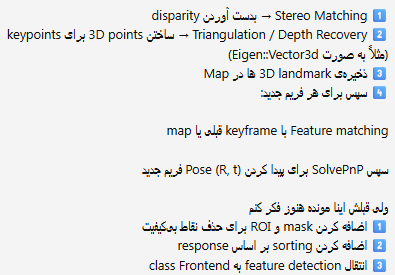

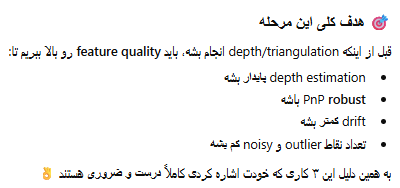

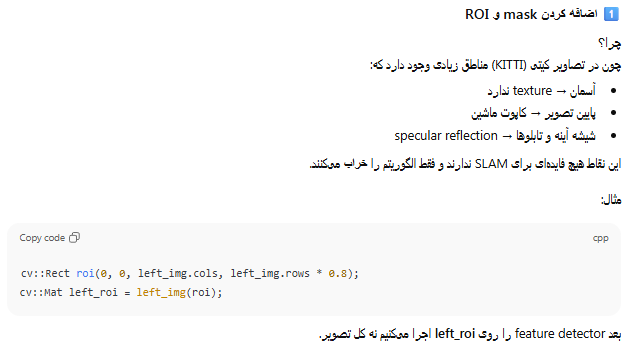

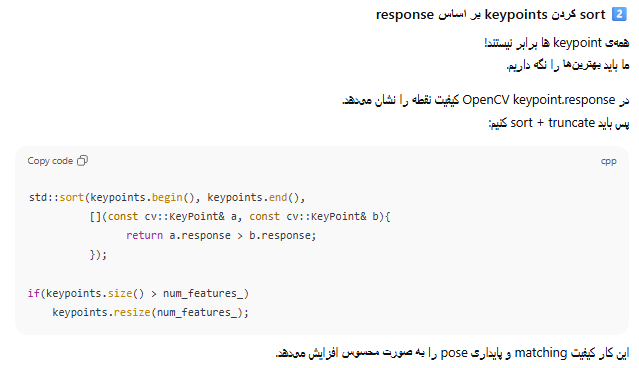

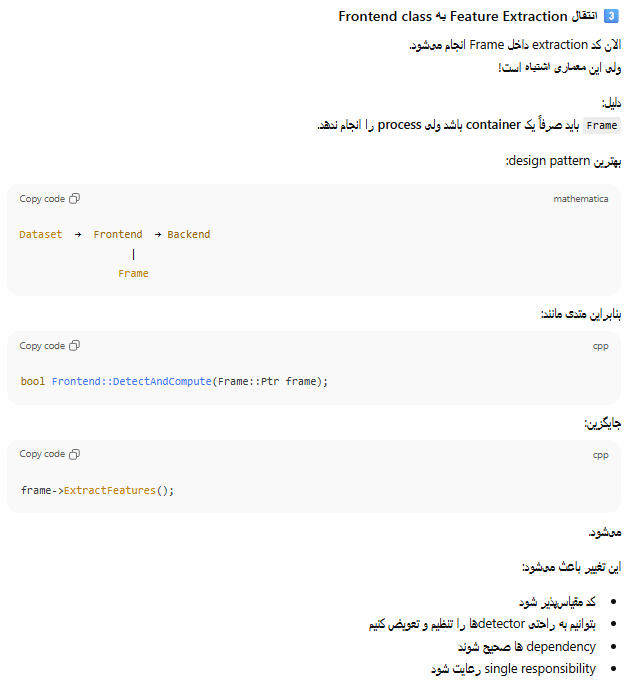

**بزززززن بررررررییییییم**

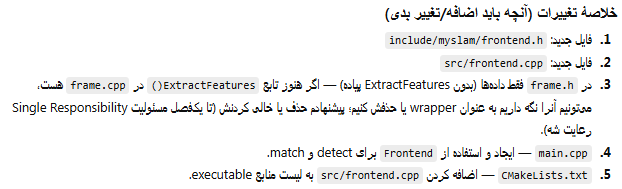

## **Headers**

In [ ]:
%cd /content/MySLAM_Ch13/include/myslam

/content/MySLAM_Ch13/include/myslam


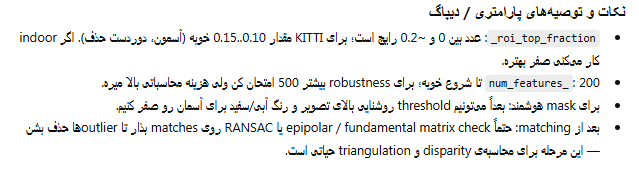

In [ ]:
%%writefile frontend.h
// include/myslam/frontend.h
#pragma once
#include "common_include.h"
#include "myslam/frame.h"

namespace myslam {

class Frontend {
public:
    typedef std::shared_ptr<Frontend> Ptr;
    EIGEN_MAKE_ALIGNED_OPERATOR_NEW

    Frontend(int num_features = 200, double roi_top_fraction = 0.0);
    ~Frontend() = default;

    // تنظیمات
    void SetNumFeatures(int n) { num_features_ = n; }
    void SetROITopFraction(double f) { roi_top_fraction_ = f; } // fraction [0..0.5] to crop top

    // API اصلی
    bool DetectAndCompute(Frame::Ptr frame); // استخراج فیچر با mask/ROI و sort by response
    void MatchStereo(Frame::Ptr frame, std::vector<cv::DMatch> &matches); // match بین چپ و راست

private:
    int num_features_;
    double roi_top_fraction_; // چه کسری از بالای تصویر را حذف کنیم
    cv::Ptr<cv::ORB> orb_;
    cv::Ptr<cv::GFTTDetector> gftt_; // optional, اگر خواستیم
    // helper
    cv::Rect ComputeROI(const cv::Mat &img) const;
    void KeepBestKeypoints(std::vector<cv::KeyPoint> &kps, cv::Mat &descriptors, int n);
};

} // namespace myslam


Writing frontend.h


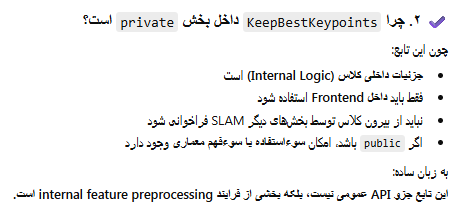

In [ ]:
%%writefile frame.h
#pragma once
#include "common_include.h"

namespace myslam {

struct Frame {
    typedef std::shared_ptr<Frame> Ptr;
    long unsigned int id = 0;
    cv::Mat left_img, right_img;
    std::vector<cv::KeyPoint> keypoints_left, keypoints_right;
    cv::Mat descriptors_left, descriptors_right;

    static Frame::Ptr CreateFrame();
    Frame() {}
};

} // namespace myslam


Overwriting frame.h


## **cpp**

In [ ]:
%cd /content/MySLAM_Ch13/src

/content/MySLAM_Ch13/src


In [ ]:
%%writefile frame.cpp

#include "myslam/frame.h"

namespace myslam {

static long unsigned int global_frame_id = 0;

Frame::Ptr Frame::CreateFrame() {
    Frame::Ptr new_frame(new Frame());
    new_frame->id = global_frame_id++;
    return new_frame;
}

}

Overwriting frame.cpp


### **frontend.cpp**

In [ ]:
%%writefile frontend.cpp

// src/frontend.cpp
#include "myslam/frontend.h"
#include <numeric>

namespace myslam {

Frontend::Frontend(int num_features, double roi_top_fraction)
    : num_features_(num_features), roi_top_fraction_(roi_top_fraction) {
    orb_ = cv::ORB::create(num_features_);
    gftt_ = cv::GFTTDetector::create(num_features_ * 2, 0.01, 20);
}

cv::Rect Frontend::ComputeROI(const cv::Mat &img) const {
    if (roi_top_fraction_ <= 0.0) return cv::Rect(0,0, img.cols, img.rows);
    int y = static_cast<int>(img.rows * roi_top_fraction_);
    int h = img.rows - y;
    return cv::Rect(0, y, img.cols, h);
}

void Frontend::KeepBestKeypoints(std::vector<cv::KeyPoint> &kps, cv::Mat &descriptors, int n) {
    if ((int)kps.size() <= n) return;
    // create indices sorted by response descending
    std::vector<int> idx(kps.size());
    std::iota(idx.begin(), idx.end(), 0);
    std::sort(idx.begin(), idx.end(), [&](int a, int b) {
        return kps[a].response > kps[b].response;
    });
    // pick top-n
    std::vector<cv::KeyPoint> kps2;
    cv::Mat desc2;
    kps2.reserve(n);
    for (int i = 0; i < n; ++i) {
        kps2.push_back(kps[idx[i]]);
        if (!descriptors.empty()) desc2.push_back(descriptors.row(idx[i]));
    }
    kps.swap(kps2);
    if (!desc2.empty()) descriptors = desc2;
}

bool Frontend::DetectAndCompute(Frame::Ptr frame) {
    if (!frame) return false;
    if (frame->left_img.empty()) return false;

    // ROI (crop top if configured)
    cv::Rect roi = ComputeROI(frame->left_img);
    cv::Mat left_roi = frame->left_img(roi);

    // Optional: create mask (exclude top small stripe or other rules)
    cv::Mat mask = cv::Mat::ones(left_roi.size(), CV_8U) * 255;
    // Example: exclude top 5% of roi (if you want more advanced mask, change here)
    // int exclude_h = static_cast<int>(0.05 * left_roi.rows);
    // if (exclude_h > 0) mask(cv::Rect(0,0,left_roi.cols, exclude_h)) = 0;

    // Detect+Compute on ROI
    std::vector<cv::KeyPoint> kps_left;
    cv::Mat desc_left;
    orb_->detectAndCompute(left_roi, mask, kps_left, desc_left);

    // adjust keypoint coordinates to original image coords
    for (auto &kp : kps_left) {
        kp.pt.x += roi.x;
        kp.pt.y += roi.y;
    }

    // Right image: detect on same ROI (or full image); here use same ROI for symmetry
    cv::Mat right_roi;
    std::vector<cv::KeyPoint> kps_right;
    cv::Mat desc_right;
    if (!frame->right_img.empty()) {
        right_roi = frame->right_img(roi);
        orb_->detectAndCompute(right_roi, mask, kps_right, desc_right);
        for (auto &kp : kps_right) {
            kp.pt.x += roi.x;
            kp.pt.y += roi.y;
        }
    }

    // Keep best by response
    KeepBestKeypoints(kps_left, desc_left, num_features_);
    if (!kps_right.empty()) KeepBestKeypoints(kps_right, desc_right, num_features_);

    // assign to frame
    frame->keypoints_left = std::move(kps_left);
    frame->descriptors_left = std::move(desc_left);
    frame->keypoints_right = std::move(kps_right);
    frame->descriptors_right = std::move(desc_right);

    return true;
}

void Frontend::MatchStereo(Frame::Ptr frame, std::vector<cv::DMatch> &matches) {
    matches.clear();
    if (!frame) return;
    if (frame->descriptors_left.empty() || frame->descriptors_right.empty()) return;

    cv::BFMatcher matcher(cv::NORM_HAMMING, true); // crossCheck = true
    matcher.match(frame->descriptors_left, frame->descriptors_right, matches);

    // sort by distance (best first)
    std::sort(matches.begin(), matches.end(), [](const cv::DMatch &a, const cv::DMatch &b){
        return a.distance < b.distance;
    });

    // optional: keep top ratio
    int keep = std::min<int>(matches.size(), num_features_);
    matches.resize(keep);
}

} // namespace myslam


Overwriting frontend.cpp


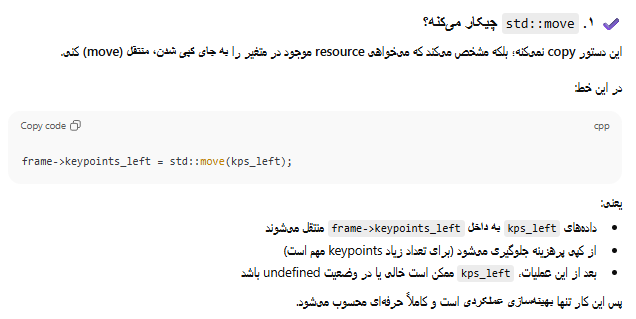

### **main.cpp**

In [ ]:
%%writefile main.cpp

#include "myslam/common_include.h"
#include "myslam/dataset.h"
#include "myslam/frame.h"
#include "myslam/frontend.h"
#include "myslam/logger.h"

using namespace myslam;

int main(int argc, char** argv) {
    if (argc != 2) {
        Log(ERRORL, "Usage: run_dataset <dataset_directory>");
        return -1;
    }
    Dataset::Ptr ds(new Dataset(argv[1]));
    if (!ds->Init()) {
        Log(ERRORL, "Dataset init failed!");
        return -1;
    }
    Frontend::Ptr frontend(new Frontend(200, 0.12)); // keep 200 features, crop top 12%
    Log(INFO, "Total frames: " + std::to_string(ds->ImageCount()));

    int frame_id = 0;
    int ii = 0;

    while (ii < 20) {
        auto frame = ds->NextFrame();
        if (!frame) break;

        ii = frame->id;

        Log(INFO, "Processing Frame: " + std::to_string(frame->id));

        if (!frontend->DetectAndCompute(frame)) {
            Log(WARNING, "Detect failed for frame " + std::to_string(frame->id));
            continue;
        }
        Log(DEBUGL, "Keypoints L: " + std::to_string(frame->keypoints_left.size())
                    + " R: " + std::to_string(frame->keypoints_right.size()));

        std::string kp_fname = "debug/keypoints_left_" + std::to_string(frame->id) + ".png";
        cv::Mat vis;
        cv::drawKeypoints(frame->left_img, frame->keypoints_left, vis, cv::Scalar(0,255,0));
        cv::imwrite(kp_fname, vis);

        std::vector<cv::DMatch> matches;
        frontend->MatchStereo(frame, matches);
        Log(DEBUGL, "Matches: " + std::to_string(matches.size()));

        cv::Mat vism;
        cv::drawMatches(frame->left_img, frame->keypoints_left,
                        frame->right_img, frame->keypoints_right,
                        matches, vism);
        cv::imwrite("debug/matches_" + std::to_string(frame->id) + ".png", vism);

        // optional: if too few matches skip triangulation later
        if (matches.size() < 20) {
            Log(WARNING, "Too few stereo matches for frame " + std::to_string(frame->id));
            continue;
        }
    }
    Log(INFO, "All frames processed.");
    return 0;
}


Overwriting main.cpp


In [ ]:
%cd /content/MySLAM_Ch13/include/myslam

/content/MySLAM_Ch13/include/myslam


In [ ]:
%%writefile logger.h

#pragma once
#include <iostream>

enum LogLevel { INFO, DEBUGL, WARNING, ERRORL };

inline void Log(LogLevel level, const std::string& msg) {
    switch(level) {
        case INFO:    std::cout << "[INFO]    " << msg << std::endl; break;
        case DEBUGL:  std::cout << "[DEBUG]   " << msg << std::endl; break;
        case WARNING: std::cout << "[WARNING] " << msg << std::endl; break;
        case ERRORL:  std::cout << "[ERROR]   " << msg << std::endl; break;
    }
}


Overwriting logger.h


## **RUN**

In [ ]:
%cd /content/MySLAM_Ch13

/content/MySLAM_Ch13


In [ ]:
%%writefile CMakeLists.txt
cmake_minimum_required(VERSION 3.10)
project(ch13_minimal)

set(CMAKE_CXX_STANDARD 17)
set(CMAKE_BUILD_TYPE Release)

set(OpenCV_DIR /usr/lib/x86_64-linux-gnu/cmake/opencv4)

find_package(OpenCV REQUIRED)
find_package(Eigen3 REQUIRED)

include_directories(${OpenCV_INCLUDE_DIRS} ${EIGEN3_INCLUDE_DIR})
include_directories(${CMAKE_SOURCE_DIR}/include)

add_executable(run_dataset
    src/main.cpp
    src/frame.cpp
    src/dataset.cpp
    src/frontend.cpp
)

target_link_libraries(run_dataset ${OpenCV_LIBS})


Overwriting CMakeLists.txt


In [ ]:
!rm -r build

In [ ]:
!mkdir build
%cd build
!mkdir debug
!cmake ..
!make

/content/MySLAM_Ch13/build
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Found OpenCV: /usr (found version "4.5.4")
-- Configuring done (0.4s)
-- Generating done (0.0s)
-- Build files have been written to: /content/MySLAM_Ch13/build
[ 20%] Building CXX object CMakeFiles/run_dataset.dir/src/main.cpp.o
[ 40%] Building CXX object CMakeFiles/run_dataset.dir/src/frame.cpp.o
[ 60%] Building CXX object CMakeFiles/run_dataset.dir/src/dataset.cpp.o
[ 80%] Building CXX object CMakeFiles/run_dataset.dir/src/frontend.cpp.o
[100%] Linking CXX ex

In [ ]:
!./run_dataset /content/gdrive/MyDrive/KITTI_Dataset/05

Dataset init: found 301 stereo pairs.
[INFO]    Total frames: 301
[INFO]    Processing Frame: 0
[DEBUG]   Keypoints L: 200 R: 200
[DEBUG]   Matches: 102
[INFO]    Processing Frame: 1
[DEBUG]   Keypoints L: 200 R: 200
[DEBUG]   Matches: 93
[INFO]    Processing Frame: 2
[DEBUG]   Keypoints L: 200 R: 200
[DEBUG]   Matches: 94
[INFO]    Processing Frame: 3
[DEBUG]   Keypoints L: 200 R: 200
[DEBUG]   Matches: 103
[INFO]    Processing Frame: 4
[DEBUG]   Keypoints L: 200 R: 200
[DEBUG]   Matches: 99
[INFO]    Processing Frame: 5
[DEBUG]   Keypoints L: 200 R: 200
[DEBUG]   Matches: 91
[INFO]    Processing Frame: 6
[DEBUG]   Keypoints L: 200 R: 200
[DEBUG]   Matches: 102
[INFO]    Processing Frame: 7
[DEBUG]   Keypoints L: 200 R: 200
[DEBUG]   Matches: 107
[INFO]    Processing Frame: 8
[DEBUG]   Keypoints L: 200 R: 200
[DEBUG]   Matches: 96
[INFO]    Processing Frame: 9
[DEBUG]   Keypoints L: 200 R: 200
[DEBUG]   Matches: 93
[INFO]    Processing Frame: 10
[DEBUG]   Keypoints L: 200 R: 200
[DEBU

# **Step 5: Improve Feature Quality (Angle Filtering)**

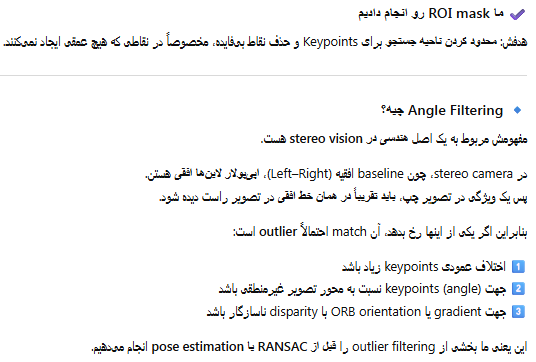

## **cpp**

In [ ]:
%cd /content/MySLAM_Ch13/src

/content/MySLAM_Ch13/src


### **frontend.cpp**

In [ ]:
%%writefile frontend.cpp

// src/frontend.cpp
#include "myslam/frontend.h"
#include <numeric>

namespace myslam {

Frontend::Frontend(int num_features, double roi_top_fraction)
    : num_features_(num_features), roi_top_fraction_(roi_top_fraction) {
    orb_ = cv::ORB::create(num_features_);
    gftt_ = cv::GFTTDetector::create(num_features_ * 2, 0.01, 20);
}

cv::Rect Frontend::ComputeROI(const cv::Mat &img) const {
    if (roi_top_fraction_ <= 0.0) return cv::Rect(0,0, img.cols, img.rows);
    int y = static_cast<int>(img.rows * roi_top_fraction_);
    int h = img.rows - y;
    return cv::Rect(0, y, img.cols, h);
}

void Frontend::KeepBestKeypoints(std::vector<cv::KeyPoint> &kps, cv::Mat &descriptors, int n) {
    if ((int)kps.size() <= n) return;
    // create indices sorted by response descending
    std::vector<int> idx(kps.size());
    std::iota(idx.begin(), idx.end(), 0);
    std::sort(idx.begin(), idx.end(), [&](int a, int b) {
        return kps[a].response > kps[b].response;
    });
    // pick top-n
    std::vector<cv::KeyPoint> kps2;
    cv::Mat desc2;
    kps2.reserve(n);
    for (int i = 0; i < n; ++i) {
        kps2.push_back(kps[idx[i]]);
        if (!descriptors.empty()) desc2.push_back(descriptors.row(idx[i]));
    }
    kps.swap(kps2);
    if (!desc2.empty()) descriptors = desc2;
}

bool Frontend::DetectAndCompute(Frame::Ptr frame) {
    if (!frame) return false;
    if (frame->left_img.empty()) return false;

    // ROI (crop top if configured)
    cv::Rect roi = ComputeROI(frame->left_img);
    cv::Mat left_roi = frame->left_img(roi);

    // Optional: create mask (exclude top small stripe or other rules)
    cv::Mat mask = cv::Mat::ones(left_roi.size(), CV_8U) * 255;
    // Example: exclude top 5% of roi (if you want more advanced mask, change here)
    // int exclude_h = static_cast<int>(0.05 * left_roi.rows);
    // if (exclude_h > 0) mask(cv::Rect(0,0,left_roi.cols, exclude_h)) = 0;

    // Detect+Compute on ROI
    std::vector<cv::KeyPoint> kps_left;
    cv::Mat desc_left;
    orb_->detectAndCompute(left_roi, mask, kps_left, desc_left);

    // adjust keypoint coordinates to original image coords
    for (auto &kp : kps_left) {
        kp.pt.x += roi.x;
        kp.pt.y += roi.y;
    }

    // Right image: detect on same ROI (or full image); here use same ROI for symmetry
    cv::Mat right_roi;
    std::vector<cv::KeyPoint> kps_right;
    cv::Mat desc_right;
    if (!frame->right_img.empty()) {
        right_roi = frame->right_img(roi);
        orb_->detectAndCompute(right_roi, mask, kps_right, desc_right);
        for (auto &kp : kps_right) {
            kp.pt.x += roi.x;
            kp.pt.y += roi.y;
        }
    }

    // Keep best by response
    KeepBestKeypoints(kps_left, desc_left, num_features_);
    if (!kps_right.empty()) KeepBestKeypoints(kps_right, desc_right, num_features_);

    // assign to frame
    frame->keypoints_left = std::move(kps_left);
    frame->descriptors_left = std::move(desc_left);
    frame->keypoints_right = std::move(kps_right);
    frame->descriptors_right = std::move(desc_right);

    return true;
}

void Frontend::MatchStereo(Frame::Ptr frame, std::vector<cv::DMatch> &matches) {
    matches.clear();
    if (!frame) return;
    if (frame->descriptors_left.empty() || frame->descriptors_right.empty()) return;

    // Step 1: brute-force matching
    cv::BFMatcher matcher(cv::NORM_HAMMING, true); // crossCheck = true
    std::vector<cv::DMatch> raw_matches;
    matcher.match(frame->descriptors_left, frame->descriptors_right, raw_matches);

    // Step 2: filtering based on epipolar constraint and angle similarity
    const double max_y_diff = 2.0;
    const double max_angle_diff = 30.0;

    for (auto& m : raw_matches) {
        const auto& kpL = frame->keypoints_left[m.queryIdx];
        const auto& kpR = frame->keypoints_right[m.trainIdx];

        if (std::fabs(kpL.pt.y - kpR.pt.y) > max_y_diff)
            continue;

        if (std::fabs(kpL.angle - kpR.angle) > max_angle_diff)
            continue;

        matches.push_back(m);
    }

    // Step 3: sort by descriptor distance
    std::sort(matches.begin(), matches.end(), [](const cv::DMatch &a, const cv::DMatch &b){
        return a.distance < b.distance;
    });

    // Step 4: keep only N best if needed
    int keep = std::min<int>(matches.size(), num_features_);
    matches.resize(keep);

    std::cout << "[Stereo Match] Raw: " << raw_matches.size()
              << "  After Filter: " << matches.size() << std::endl;
}

} // namespace myslam


Overwriting frontend.cpp


## **RUN**

In [ ]:
%cd /content/MySLAM_Ch13

/content/MySLAM_Ch13


In [ ]:
!rm -r build

In [ ]:
!mkdir build
%cd build
!mkdir debug
!cmake ..
!make

/content/MySLAM_Ch13/build
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Found OpenCV: /usr (found version "4.5.4")
-- Configuring done (0.4s)
-- Generating done (0.0s)
-- Build files have been written to: /content/MySLAM_Ch13/build
[ 20%] Building CXX object CMakeFiles/run_dataset.dir/src/main.cpp.o
[ 40%] Building CXX object CMakeFiles/run_dataset.dir/src/frame.cpp.o
[ 60%] Building CXX object CMakeFiles/run_dataset.dir/src/dataset.cpp.o
[ 80%] Building CXX object CMakeFiles/run_dataset.dir/src/frontend.cpp.o
[100%] Linking CXX ex

In [ ]:
!./run_dataset /content/gdrive/MyDrive/KITTI_Dataset/05

Dataset init: found 301 stereo pairs.
[INFO]    Total frames: 301
[INFO]    Processing Frame: 0
[DEBUG]   Keypoints L: 200 R: 200
[Stereo Match] Raw: 102  After Filter: 71
[DEBUG]   Matches: 71
[INFO]    Processing Frame: 1
[DEBUG]   Keypoints L: 200 R: 200
[Stereo Match] Raw: 93  After Filter: 75
[DEBUG]   Matches: 75
[INFO]    Processing Frame: 2
[DEBUG]   Keypoints L: 200 R: 200
[Stereo Match] Raw: 94  After Filter: 61
[DEBUG]   Matches: 61
[INFO]    Processing Frame: 3
[DEBUG]   Keypoints L: 200 R: 200
[Stereo Match] Raw: 103  After Filter: 67
[DEBUG]   Matches: 67
[INFO]    Processing Frame: 4
[DEBUG]   Keypoints L: 200 R: 200
[Stereo Match] Raw: 99  After Filter: 69
[DEBUG]   Matches: 69
[INFO]    Processing Frame: 5
[DEBUG]   Keypoints L: 200 R: 200
[Stereo Match] Raw: 91  After Filter: 65
[DEBUG]   Matches: 65
[INFO]    Processing Frame: 6
[DEBUG]   Keypoints L: 200 R: 200
[Stereo Match] Raw: 102  After Filter: 83
[DEBUG]   Matches: 83
[INFO]    Processing Frame: 7
[DEBUG]   Ke

# **Step 6: Disparity and Triangulation**

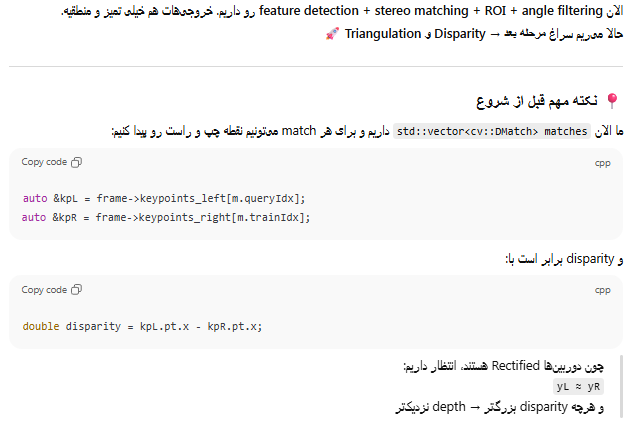

## **cpp**

In [ ]:
%cd /content/MySLAM_Ch13/src

/content/MySLAM_Ch13/src


In [ ]:
%%writefile frame.cpp

#include "myslam/frame.h"

namespace myslam {

static long unsigned int global_frame_id = 0;

Frame::Ptr Frame::CreateFrame() {
    Frame::Ptr new_frame(new Frame());
    new_frame->id = global_frame_id++;
    return new_frame;
}

}

Overwriting frame.cpp


### **frontend.cpp**

In [ ]:
%%writefile frontend.cpp

// src/frontend.cpp
#include "myslam/frontend.h"
#include <numeric>

namespace myslam {

Frontend::Frontend(int num_features, double roi_top_fraction)
    : num_features_(num_features), roi_top_fraction_(roi_top_fraction) {
    orb_ = cv::ORB::create(num_features_);
    gftt_ = cv::GFTTDetector::create(num_features_ * 2, 0.01, 20);
}

cv::Rect Frontend::ComputeROI(const cv::Mat &img) const {
    if (roi_top_fraction_ <= 0.0) return cv::Rect(0,0, img.cols, img.rows);
    int y = static_cast<int>(img.rows * roi_top_fraction_);
    int h = img.rows - y;
    return cv::Rect(0, y, img.cols, h);
}

void Frontend::KeepBestKeypoints(std::vector<cv::KeyPoint> &kps, cv::Mat &descriptors, int n) {
    if ((int)kps.size() <= n) return;
    // create indices sorted by response descending
    std::vector<int> idx(kps.size());
    std::iota(idx.begin(), idx.end(), 0);
    std::sort(idx.begin(), idx.end(), [&](int a, int b) {
        return kps[a].response > kps[b].response;
    });
    // pick top-n
    std::vector<cv::KeyPoint> kps2;
    cv::Mat desc2;
    kps2.reserve(n);
    for (int i = 0; i < n; ++i) {
        kps2.push_back(kps[idx[i]]);
        if (!descriptors.empty()) desc2.push_back(descriptors.row(idx[i]));
    }
    kps.swap(kps2);
    if (!desc2.empty()) descriptors = desc2;
}

bool Frontend::DetectAndCompute(Frame::Ptr frame) {
    if (!frame) return false;
    if (frame->left_img.empty()) return false;

    // ROI (crop top if configured)
    cv::Rect roi = ComputeROI(frame->left_img);
    cv::Mat left_roi = frame->left_img(roi);

    // Optional: create mask (exclude top small stripe or other rules)
    cv::Mat mask = cv::Mat::ones(left_roi.size(), CV_8U) * 255;
    // Example: exclude top 5% of roi (if you want more advanced mask, change here)
    // int exclude_h = static_cast<int>(0.05 * left_roi.rows);
    // if (exclude_h > 0) mask(cv::Rect(0,0,left_roi.cols, exclude_h)) = 0;

    // Detect+Compute on ROI
    std::vector<cv::KeyPoint> kps_left;
    cv::Mat desc_left;
    orb_->detectAndCompute(left_roi, mask, kps_left, desc_left);

    // adjust keypoint coordinates to original image coords
    for (auto &kp : kps_left) {
        kp.pt.x += roi.x;
        kp.pt.y += roi.y;
    }

    // Right image: detect on same ROI (or full image); here use same ROI for symmetry
    cv::Mat right_roi;
    std::vector<cv::KeyPoint> kps_right;
    cv::Mat desc_right;
    if (!frame->right_img.empty()) {
        right_roi = frame->right_img(roi);
        orb_->detectAndCompute(right_roi, mask, kps_right, desc_right);
        for (auto &kp : kps_right) {
            kp.pt.x += roi.x;
            kp.pt.y += roi.y;
        }
    }

    // Keep best by response
    KeepBestKeypoints(kps_left, desc_left, num_features_);
    if (!kps_right.empty()) KeepBestKeypoints(kps_right, desc_right, num_features_);

    // assign to frame
    frame->keypoints_left = std::move(kps_left);
    frame->descriptors_left = std::move(desc_left);
    frame->keypoints_right = std::move(kps_right);
    frame->descriptors_right = std::move(desc_right);

    return true;
}


void Frontend::ComputeStereoDepth(Frame::Ptr frame, const std::vector<cv::DMatch> &matches) {

    const double fx = camera_left_->fx();
    const double fy = camera_left_->fy();
    const double cx = camera_left_->cx();
    const double cy = camera_left_->cy();
    const double baseline = camera_right_->baseline();

    frame->points_3d.clear();
    frame->points_3d.reserve(matches.size());

    for(const auto &m : matches) {
        const cv::KeyPoint &kpL = frame->keypoints_left[m.queryIdx];
        const cv::KeyPoint &kpR = frame->keypoints_right[m.trainIdx];

        double disparity = kpL.pt.x - kpR.pt.x;
        if(disparity <= 0.5) continue;

        double Z = fx * baseline / disparity;
        double X = (kpL.pt.x - cx) * Z / fx;
        double Y = (kpL.pt.y - cy) * Z / fy;

        frame->points_3d.emplace_back(Eigen::Vector3d(X, Y, Z));
    }

    std::cout << "[Depth] Valid 3D points: " << frame->points_3d.size() << std::endl;
}

void Frontend::SetCameras(Camera::Ptr cam_left, Camera::Ptr cam_right) {
    camera_left_ = cam_left;
    camera_right_ = cam_right;
}


void Frontend::MatchStereo(Frame::Ptr frame, std::vector<cv::DMatch> &matches) {
    matches.clear();
    if (!frame) return;
    if (frame->descriptors_left.empty() || frame->descriptors_right.empty()) return;

    // Step 1: brute-force matching
    cv::BFMatcher matcher(cv::NORM_HAMMING, true); // crossCheck = true
    std::vector<cv::DMatch> raw_matches;
    matcher.match(frame->descriptors_left, frame->descriptors_right, raw_matches);

    // Step 2: filtering based on epipolar constraint and angle similarity
    const double max_y_diff = 2.0;
    const double max_angle_diff = 30.0;

    for (auto& m : raw_matches) {
        const auto& kpL = frame->keypoints_left[m.queryIdx];
        const auto& kpR = frame->keypoints_right[m.trainIdx];

        if (std::fabs(kpL.pt.y - kpR.pt.y) > max_y_diff)
            continue;

        if (std::fabs(kpL.angle - kpR.angle) > max_angle_diff)
            continue;

        matches.push_back(m);
    }

    // Step 3: sort by descriptor distance
    std::sort(matches.begin(), matches.end(), [](const cv::DMatch &a, const cv::DMatch &b){
        return a.distance < b.distance;
    });

    // Step 4: keep only N best if needed
    int keep = std::min<int>(matches.size(), num_features_);
    matches.resize(keep);

    std::cout << "[Stereo Match] Raw: " << raw_matches.size()
              << "  After Filter: " << matches.size() << std::endl;

    // Step 5
    ComputeStereoDepth(frame, matches);

}

} // namespace myslam


Overwriting frontend.cpp


In [ ]:
%%writefile camera.cpp

#include "myslam/camera.h"

namespace myslam {
// Nothing needed here for now (all inline getters)
}


Overwriting camera.cpp


### **dataset.cpp**

In [ ]:
%%writefile dataset.cpp

// src/dataset.cpp
#include "myslam/dataset.h"
#include "myslam/common_include.h"
#include "myslam/frame.h"   // اکنون از Frame واقعی استفاده می‌کنیم

namespace myslam {

Dataset::Dataset(const std::string& dataset_path) : dataset_path_(dataset_path) {}

bool Dataset::Init() {
    namespace fs = std::filesystem;
    std::string left_dir = dataset_path_ + "/image_0";
    std::string right_dir = dataset_path_ + "/image_1";

    if (!fs::exists(left_dir) || !fs::exists(right_dir)) {
        std::cerr << "Dataset folders not found: " << left_dir << " or " << right_dir << std::endl;
        return false;
    }

    left_images_.clear();
    right_images_.clear();

    for (auto &p : fs::directory_iterator(left_dir)) left_images_.push_back(p.path().string());
    for (auto &p : fs::directory_iterator(right_dir)) right_images_.push_back(p.path().string());

    std::sort(left_images_.begin(), left_images_.end());
    std::sort(right_images_.begin(), right_images_.end());

    if (left_images_.size() != right_images_.size()) {
        std::cerr << "Left and right image counts differ!" << std::endl;
        size_t n = std::min(left_images_.size(), right_images_.size());
        left_images_.resize(n);
        right_images_.resize(n);
    }

    std::cout << "Dataset init: found " << left_images_.size() << " stereo pairs.\n";
    return true;
}

Dataset::FramePtr Dataset::NextFrame() {
    if (current_image_index_ >= static_cast<int>(left_images_.size())) return nullptr;

    cv::Mat left = cv::imread(left_images_[current_image_index_], cv::IMREAD_GRAYSCALE);
    cv::Mat right = cv::imread(right_images_[current_image_index_], cv::IMREAD_GRAYSCALE);

    if (left.empty() || right.empty()) {
        std::cerr << "Failed to read images at index " << current_image_index_ << std::endl;
        return nullptr;
    }

    Frame::Ptr f = Frame::CreateFrame();
    f->left_img = left;
    f->right_img = right;

    current_image_index_++;
    return f;
}

} // namespace myslam


Overwriting dataset.cpp


### **main.cpp**

In [ ]:
%%writefile main.cpp

#include "myslam/common_include.h"
#include "myslam/dataset.h"
#include "myslam/frame.h"
#include "myslam/frontend.h"
#include "myslam/logger.h"

using namespace myslam;

int main(int argc, char** argv) {
    if (argc != 2) {
        Log(ERRORL, "Usage: run_dataset <dataset_directory>");
        return -1;
    }
    Dataset::Ptr ds(new Dataset(argv[1]));
    if (!ds->Init()) {
        Log(ERRORL, "Dataset init failed!");
        return -1;
    }
    Frontend::Ptr frontend(new Frontend(200, 0.12)); // keep 200 features, crop top 12%
    Log(INFO, "Total frames: " + std::to_string(ds->ImageCount()));

    auto camL = std::make_shared<myslam::Camera>(718.856, 718.856, 607.1928, 185.2157, 0.573);
    auto camR = std::make_shared<myslam::Camera>(718.856, 718.856, 607.1928, 185.2157, 0.573);

    frontend->SetCameras(camL, camR);

    int frame_id = 0;
    //std::cout << "frame_id: " << frame_id;
    int ii = 0;

    while (ii < 20) {
      auto frame = ds->NextFrame();
      if (!frame) {
      Log(ERRORL, "Frame is null!");
      break;
      }

      if (frame->left_img.empty() || frame->right_img.empty()) {
          Log(ERRORL, "Empty image at frame " + std::to_string(frame->id));
          return -1;
      }

      Log(INFO, "Images loaded, size L: " + std::to_string(frame->left_img.cols) + "x" + std::to_string(frame->left_img.rows) +
                " R: " + std::to_string(frame->right_img.cols) + "x" + std::to_string(frame->right_img.rows));

      ii = frame->id;
      Log(INFO, "Processing Frame: " + std::to_string(frame->id));

      // Check image validity
      if (frame->left_img.empty() || frame->right_img.empty()) {
      Log(ERRORL, "Empty image at frame " + std::to_string(frame->id));
      continue;
      }

      // Feature detection
      if (!frontend->DetectAndCompute(frame)) {
          Log(WARNING, "Detect failed for frame " + std::to_string(frame->id));
          continue;
      }

      // Check keypoints size
      if (frame->keypoints_left.empty() || frame->keypoints_right.empty()) {
          Log(WARNING, "No keypoints detected at frame " + std::to_string(frame->id));
          continue;
      }

      Log(DEBUGL, "Keypoints L: " + std::to_string(frame->keypoints_left.size())
                  + " R: " + std::to_string(frame->keypoints_right.size()));

      // Visualization
      cv::Mat vis;
      cv::drawKeypoints(frame->left_img, frame->keypoints_left, vis);
      cv::imwrite("debug/keypoints_left_" + std::to_string(frame->id) + ".png", vis);

      Log(INFO, "kps L = " + std::to_string(frame->keypoints_left.size()) +
              " | R = " + std::to_string(frame->keypoints_right.size()));


      std::vector<cv::DMatch> matches;
      frontend->MatchStereo(frame, matches);

      Log(DEBUGL, "Matches: " + std::to_string(matches.size()));

      if (matches.size() < 20) {
          Log(WARNING, "Too few stereo matches for frame " + std::to_string(frame->id));
          continue;
    }
}

    Log(INFO, "All frames processed.");
    return 0;
}


Overwriting main.cpp


## **Headers**

In [ ]:
%cd /content/MySLAM_Ch13/include/myslam

/content/MySLAM_Ch13/include/myslam


In [ ]:
%%writefile frame.h
#pragma once
#include "common_include.h"

namespace myslam {

struct Frame {
    typedef std::shared_ptr<Frame> Ptr;
    long unsigned int id = 0;
    cv::Mat left_img, right_img;
    std::vector<cv::KeyPoint> keypoints_left, keypoints_right;
    cv::Mat descriptors_left, descriptors_right;

    static Frame::Ptr CreateFrame();
    Frame() {}
};

} // namespace myslam


Overwriting frame.h


In [ ]:
%%writefile common_include.h
// include/myslam/common_include.h
#ifndef MYSLAM_COMMON_INCLUDE_H
#define MYSLAM_COMMON_INCLUDE_H

// C++
#include <iostream>
#include <memory>
#include <vector>
#include <string>
#include <mutex>
#include <filesystem> // C++17

// Eigen
#include <Eigen/Dense>

// OpenCV
#include <opencv2/opencv.hpp>

#endif // MYSLAM_COMMON_INCLUDE_H


Overwriting common_include.h


In [ ]:
%%writefile logger.h

#pragma once
#include <iostream>

enum LogLevel { INFO, DEBUGL, WARNING, ERRORL };

inline void Log(LogLevel level, const std::string& msg) {
    switch(level) {
        case INFO:    std::cout << "[INFO]    " << msg << std::endl; break;
        case DEBUGL:  std::cout << "[DEBUG]   " << msg << std::endl; break;
        case WARNING: std::cout << "[WARNING] " << msg << std::endl; break;
        case ERRORL:  std::cout << "[ERROR]   " << msg << std::endl; break;
    }
}


Overwriting logger.h


In [ ]:
%%writefile frontend.h
// include/myslam/frontend.h
#pragma once
#include "common_include.h"
#include "frame.h"
#include "camera.h"

namespace myslam {

class Frontend {
public:
    typedef std::shared_ptr<Frontend> Ptr;

    void SetCameras(Camera::Ptr cam_left, Camera::Ptr cam_right);

    Frontend(int num_features = 200, double roi_top_fraction = 0.0);
    ~Frontend() = default;

    // setting
    void SetNumFeatures(int n) { num_features_ = n; }
    void SetROITopFraction(double f) { roi_top_fraction_ = f; } // fraction [0..0.5] to crop top

    // Main API
    bool DetectAndCompute(Frame::Ptr frame); // استخراج فیچر با mask/ROI و sort by response
    void MatchStereo(Frame::Ptr frame, std::vector<cv::DMatch> &matches); // match بین چپ و راست
    void ComputeStereoDepth(Frame::Ptr frame, const std::vector<cv::DMatch> &matches);

private:
    Camera::Ptr camera_left_ = nullptr;
    Camera::Ptr camera_right_ = nullptr;

    int num_features_;
    double roi_top_fraction_; // The portion need to be removed
    cv::Ptr<cv::ORB> orb_;
    cv::Ptr<cv::GFTTDetector> gftt_; // optional
    // helper
    cv::Rect ComputeROI(const cv::Mat &img) const;
    void KeepBestKeypoints(std::vector<cv::KeyPoint> &kps, cv::Mat &descriptors, int n);
};

} // namespace myslam


Overwriting frontend.h


In [ ]:
%%writefile frame.h
#pragma once
#include "common_include.h"

namespace myslam {

struct Frame {
    typedef std::shared_ptr<Frame> Ptr;
    long unsigned int id = 0;
    cv::Mat left_img, right_img;
    std::vector<cv::KeyPoint> keypoints_left, keypoints_right;
    cv::Mat descriptors_left, descriptors_right;

    static Frame::Ptr CreateFrame();
    Frame() {}

    public:
    std::vector<Eigen::Vector3d> points_3d;  // 3D points from stereo

};

} // namespace myslam

Overwriting frame.h


In [ ]:
%%writefile camera.h
#pragma once
#include "common_include.h"

namespace myslam {

class Camera {
public:
    using Ptr = std::shared_ptr<Camera>;

    Camera(double fx, double fy, double cx, double cy, double baseline)
        : fx_(fx), fy_(fy), cx_(cx), cy_(cy), baseline_(baseline) {}

    double fx() const { return fx_; }
    double fy() const { return fy_; }
    double cx() const { return cx_; }
    double cy() const { return cy_; }
    double baseline() const { return baseline_; }

private:
    double fx_ = 0, fy_ = 0, cx_ = 0, cy_ = 0;
    double baseline_ = 0;
};

} // namespace myslam


Overwriting camera.h


In [ ]:
%%writefile dataset.h

// include/myslam/dataset.h
#ifndef MYSLAM_DATASET_H
#define MYSLAM_DATASET_H
#include "camera.h"
#pragma once

#include "myslam/common_include.h"
#include "myslam/frame.h"

// Forward declaration of Frame to avoid heavy include here.
// فرض بر این است که در مرحله‌ی بعد از Frame::Ptr استفاده می‌کنیم
namespace myslam {
// struct Frame;
// typedef std::shared_ptr<Frame> FramePtr;

class Dataset {
public:
    EIGEN_MAKE_ALIGNED_OPERATOR_NEW;
    typedef std::shared_ptr<Dataset> Ptr;
    typedef Frame::Ptr FramePtr;   // ← این خط ضروری است

    Dataset(const std::string& dataset_path);

    // خواندن اطلاعات دیتاست (مسیرها، کالیبراسیون در نسخه‌ی کامل)
    bool Init();

    // گرفتن فریم بعدی؛ اگر تمام شده nullptr برمی‌گرداند
    FramePtr NextFrame();

    // تعداد تصاویر (کمکی)
    int ImageCount() const { return static_cast<int>(left_images_.size()); }


    std::vector<Camera::Ptr> cameras_;
    Camera::Ptr GetCamera(int idx) const {
    return cameras_.at(idx);
}

private:
    std::string dataset_path_;
    int current_image_index_ = 0;

    // لیست مسیر تصاویر چپ/راست
    std::vector<std::string> left_images_;
    std::vector<std::string> right_images_;
};

} // namespace myslam

#endif // MYSLAM_DATASET_H


Overwriting dataset.h


## **RUN**

In [ ]:
%cd /content/MySLAM_Ch13

/content/MySLAM_Ch13


In [ ]:
%%writefile CMakeLists.txt
cmake_minimum_required(VERSION 3.10)
project(ch13_minimal)

set(CMAKE_CXX_STANDARD 17)
set(CMAKE_BUILD_TYPE Release)

set(OpenCV_DIR /usr/lib/x86_64-linux-gnu/cmake/opencv4)

find_package(OpenCV REQUIRED)
find_package(Eigen3 REQUIRED)

include_directories(${OpenCV_INCLUDE_DIRS} ${EIGEN3_INCLUDE_DIR})
include_directories(${CMAKE_SOURCE_DIR}/include)

add_executable(run_dataset
    src/main.cpp
    src/frame.cpp
    src/dataset.cpp
    src/frontend.cpp
    src/camera.cpp
)

target_link_libraries(run_dataset ${OpenCV_LIBS})


Overwriting CMakeLists.txt


In [ ]:
!rm -r build

In [ ]:
!mkdir build
%cd build
!mkdir debug
!cmake ..
!make

/content/MySLAM_Ch13/build
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Found OpenCV: /usr (found version "4.5.4")
-- Configuring done (0.4s)
-- Generating done (0.0s)
-- Build files have been written to: /content/MySLAM_Ch13/build
[ 16%] Building CXX object CMakeFiles/run_dataset.dir/src/main.cpp.o
[ 33%] Building CXX object CMakeFiles/run_dataset.dir/src/frame.cpp.o
[ 50%] Building CXX object CMakeFiles/run_dataset.dir/src/dataset.cpp.o
[ 66%] Building CXX object CMakeFiles/run_dataset.dir/src/frontend.cpp.o
[ 83%] Building CXX o

In [ ]:
!./run_dataset /content/gdrive/MyDrive/KITTI_Dataset/05

Dataset init: found 301 stereo pairs.
[INFO]    Total frames: 301
[INFO]    Images loaded, size L: 1226x370 R: 1226x370
[INFO]    Processing Frame: 0
[DEBUG]   Keypoints L: 200 R: 200
[INFO]    kps L = 200 | R = 200
[Stereo Match] Raw: 102  After Filter: 71
[Depth] Valid 3D points: 71
[DEBUG]   Matches: 71
[INFO]    Images loaded, size L: 1226x370 R: 1226x370
[INFO]    Processing Frame: 1
[DEBUG]   Keypoints L: 200 R: 200
[INFO]    kps L = 200 | R = 200
[Stereo Match] Raw: 93  After Filter: 75
[Depth] Valid 3D points: 74
[DEBUG]   Matches: 75
[INFO]    Images loaded, size L: 1226x370 R: 1226x370
[INFO]    Processing Frame: 2
[DEBUG]   Keypoints L: 200 R: 200
[INFO]    kps L = 200 | R = 200
[Stereo Match] Raw: 94  After Filter: 61
[Depth] Valid 3D points: 60
[DEBUG]   Matches: 61
[INFO]    Images loaded, size L: 1226x370 R: 1226x370
[INFO]    Processing Frame: 3
[DEBUG]   Keypoints L: 200 R: 200
[INFO]    kps L = 200 | R = 200
[Stereo Match] Raw: 103  After Filter: 67
[Depth] Valid 3D p

# **Step 7: MapPoint and Map**

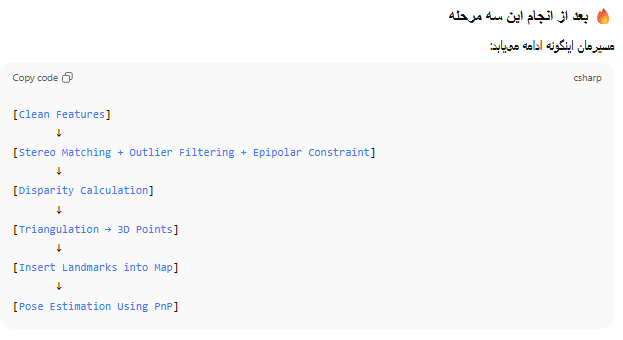

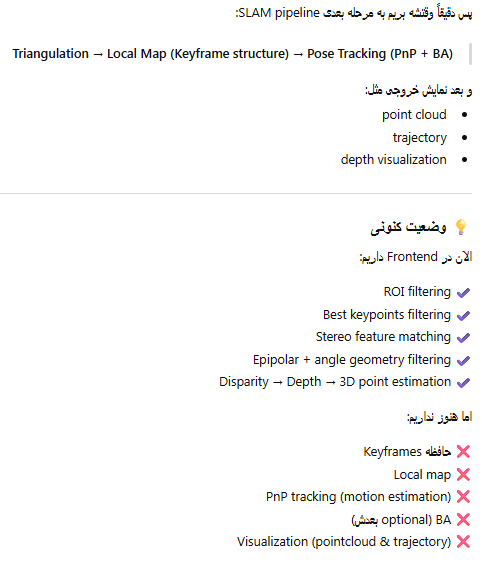

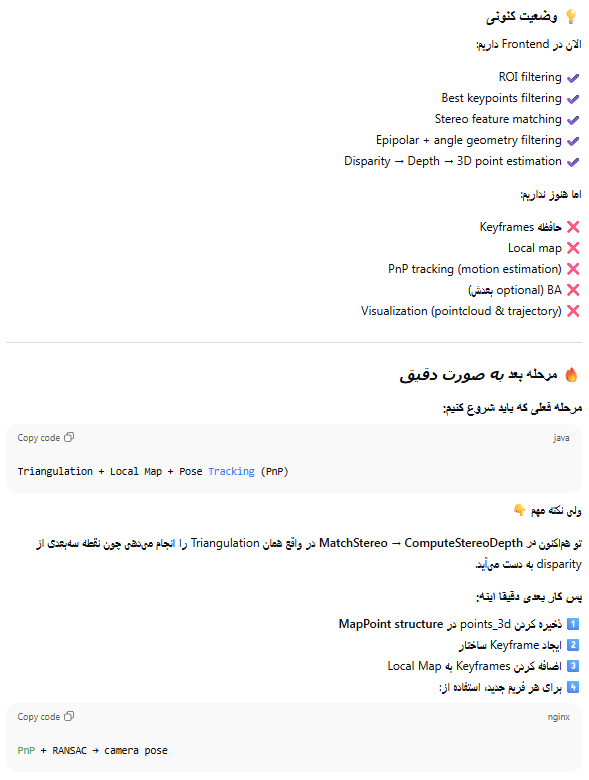

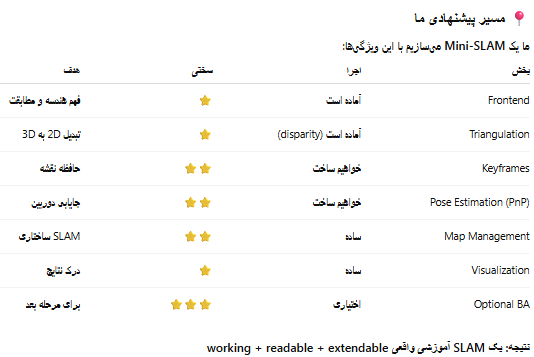

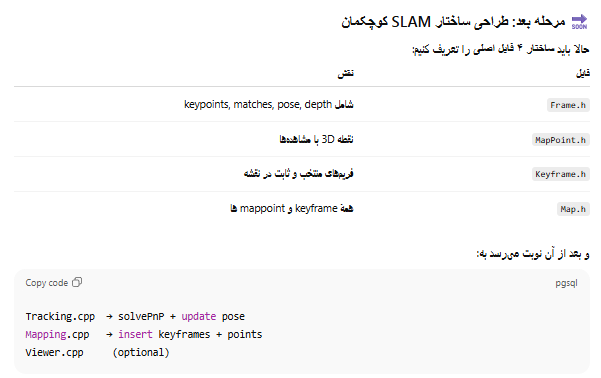

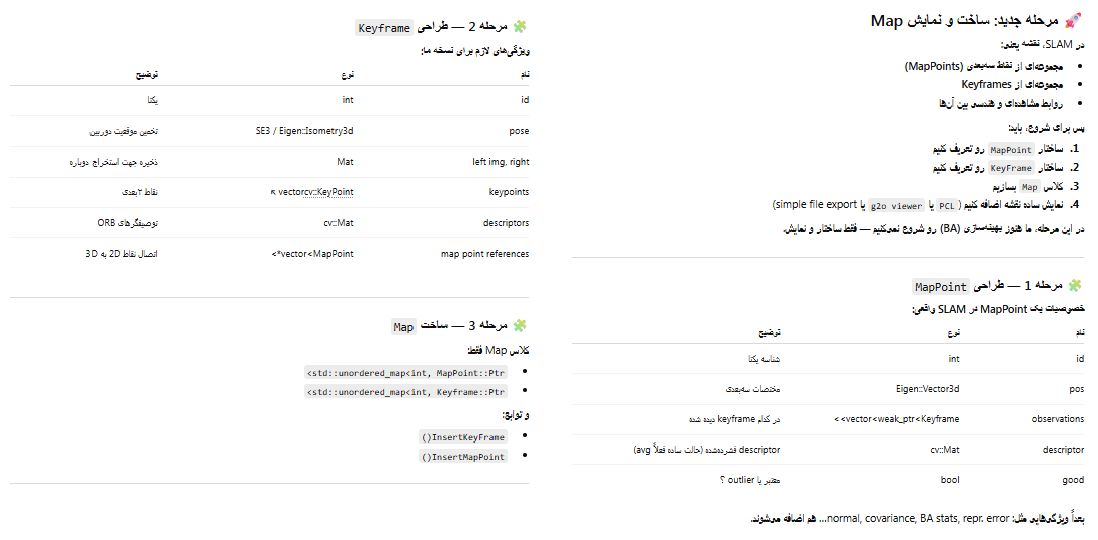

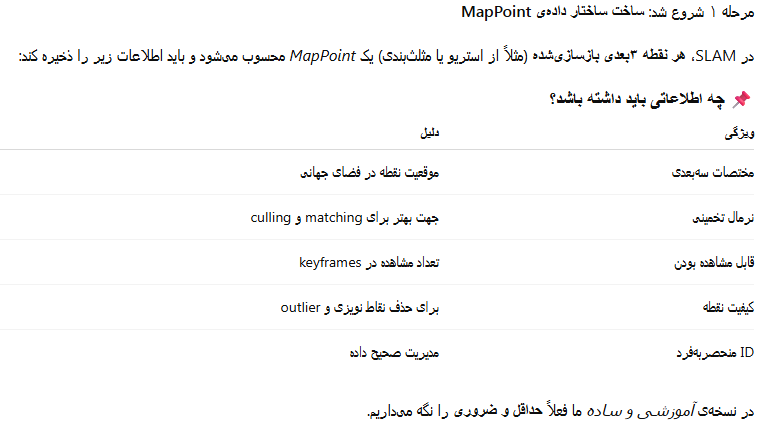

## **Headers**

In [ ]:
%cd /content/MySLAM_Ch13/include/myslam

/content/MySLAM_Ch13/include/myslam


In [ ]:
%%writefile mappoint.h

#pragma once
#include "common_include.h"

namespace myslam {

class MapPoint {
public:
    EIGEN_MAKE_ALIGNED_OPERATOR_NEW;
    using Ptr = std::shared_ptr<MapPoint>;

    unsigned long id_ = 0;          // Unique point ID
    Eigen::Vector3d pos_;           // 3D position (world coordinate)
    int observed_times_ = 0;        // Number of times observed in frames

    MapPoint() = default;

    MapPoint(long id, const Eigen::Vector3d& pos)
        : id_(id), pos_(pos) {}

    Eigen::Vector3d Pos() const { return pos_; }
    void SetPos(const Eigen::Vector3d& pos) { pos_ = pos; }

    void IncreaseObservation() { observed_times_++; }
};

} // namespace myslam



Overwriting mappoint.h


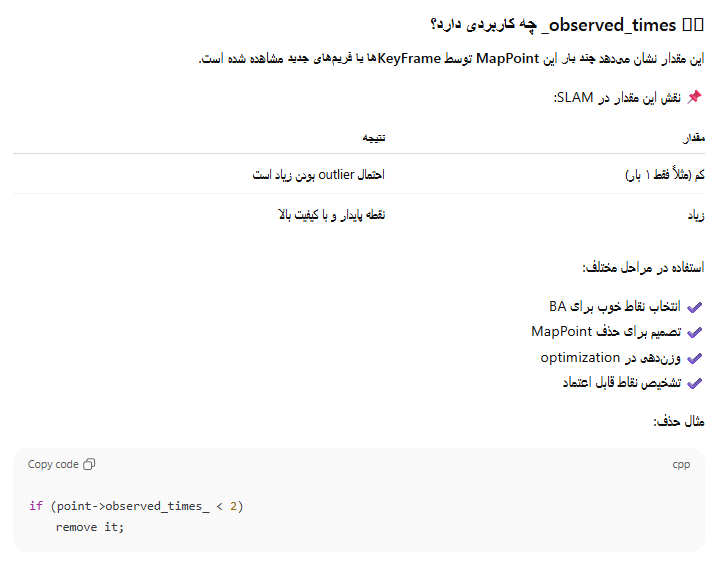

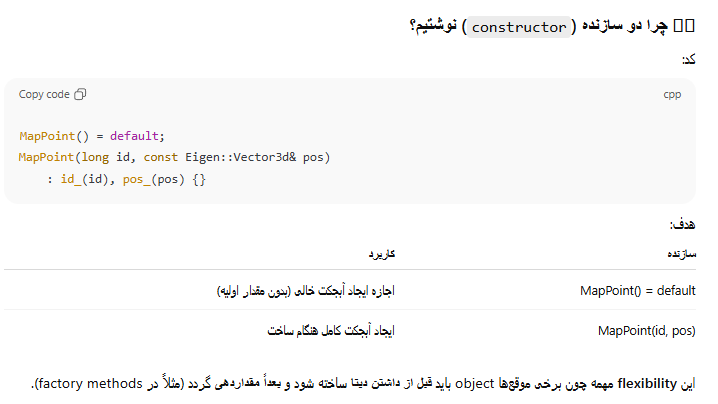

## **cpp**

In [ ]:
%cd /content/MySLAM_Ch13/src

/content/MySLAM_Ch13/src


In [ ]:
%%writefile mappoint.cpp

#include "myslam/mappoint.h"


namespace myslam {
// currently no functions, but later we will add BA related updates
}


Overwriting mappoint.cpp


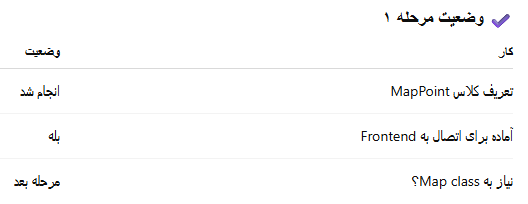

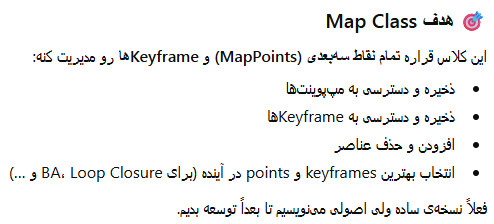

## **Headers**

In [ ]:
%cd /content/MySLAM_Ch13/include/myslam

/content/MySLAM_Ch13/include/myslam


In [ ]:
%%writefile map.h

#pragma once
#include "common_include.h"
#include "frame.h"
#include "mappoint.h"

namespace myslam {

class Map {
public:
    using Ptr = std::shared_ptr<Map>;

    std::unordered_map<unsigned long, MapPoint::Ptr> landmarks_;   // id -> 3D points
    std::unordered_map<unsigned long, Frame::Ptr> keyframes_;      // id -> frames

    Map() {}

    void InsertKeyFrame(Frame::Ptr frame) {
        keyframes_[frame->id] = frame;
        std::cout << "[Map] Inserted KeyFrame " << frame->id << std::endl;
    }

    void InsertMapPoint(MapPoint::Ptr point) {
        landmarks_[point->id_] = point;
    }

    size_t KeyframeCount() const { return keyframes_.size(); }
    size_t LandmarkCount() const { return landmarks_.size(); }
    size_t MapPointsCount() const { return landmarks_.size(); }

};

} // namespace myslam


Overwriting map.h


## **cpp**

In [ ]:
%cd /content/MySLAM_Ch13/src

/content/MySLAM_Ch13/src


In [ ]:
%%writefile map.cpp

#include "myslam/map.h"

namespace myslam {
// Placeholder for future enhancements
}


Overwriting map.cpp


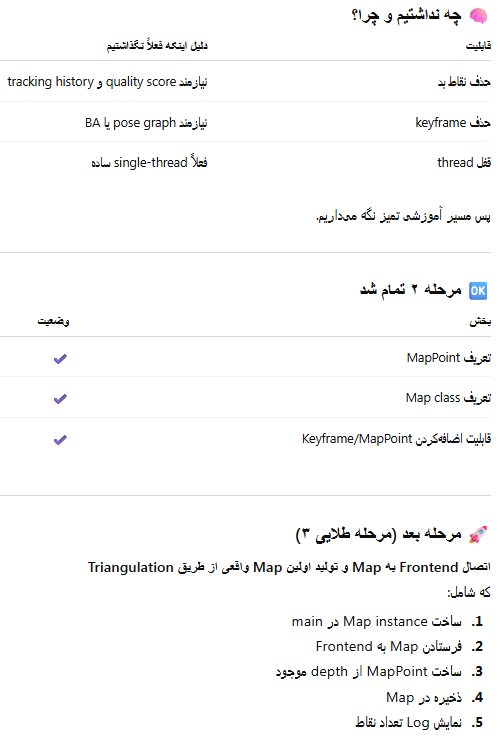

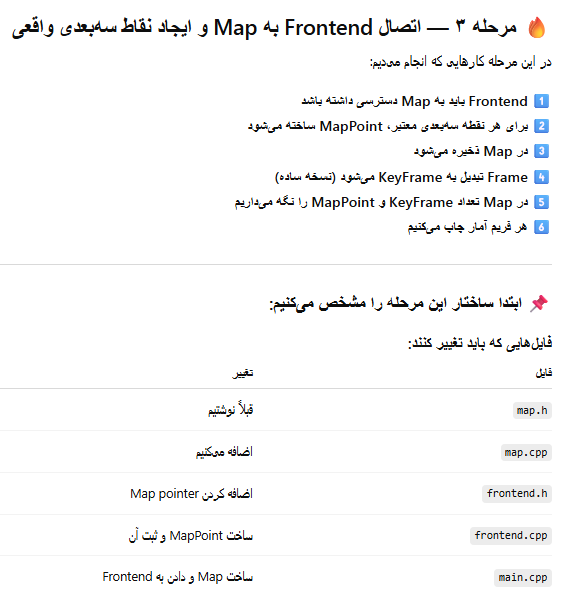

## **Headers**

In [ ]:
%cd /content/MySLAM_Ch13/include/myslam

/content/MySLAM_Ch13/include/myslam


In [ ]:
%%writefile frame.h

#pragma once
#include "common_include.h"
#include "mappoint.h"

namespace myslam {

struct Frame {
    typedef std::shared_ptr<Frame> Ptr;
    long unsigned int id = 0;
    cv::Mat left_img, right_img;
    std::vector<cv::KeyPoint> keypoints_left, keypoints_right;
    cv::Mat descriptors_left, descriptors_right;

    static Frame::Ptr CreateFrame();
    Frame() {}

    public:
        std::vector<Eigen::Vector3d> points_3d;  // 3D points from stereo
        void AddLandmark(MapPoint::Ptr mp) { landmarks_.push_back(mp); }
        const std::vector<MapPoint::Ptr>& GetLandmarks() const { return landmarks_; }

    private:
        std::vector<MapPoint::Ptr> landmarks_;

};

} // namespace myslam

Overwriting frame.h


In [ ]:
%%writefile frontend.h
// include/myslam/frontend.h
#pragma once
#include "common_include.h"
#include "frame.h"
#include "camera.h"
#include "map.h"

namespace myslam {

class Frontend {
public:
    typedef std::shared_ptr<Frontend> Ptr;

    void SetCameras(Camera::Ptr cam_left, Camera::Ptr cam_right);

    Frontend(int num_features = 200, double roi_top_fraction = 0.0);
    ~Frontend() = default;

    // تنظیمات
    void SetNumFeatures(int n) { num_features_ = n; }
    void SetROITopFraction(double f) { roi_top_fraction_ = f; } // fraction [0..0.5] to crop top

    // API اصلی
    bool DetectAndCompute(Frame::Ptr frame); // استخراج فیچر با mask/ROI و sort by response
    void MatchStereo(Frame::Ptr frame, std::vector<cv::DMatch> &matches); // match بین چپ و راست
    void ComputeStereoDepth(Frame::Ptr frame, const std::vector<cv::DMatch> &matches);

    void SetMap(Map::Ptr map) { map_ = map; }


private:
    Camera::Ptr camera_left_ = nullptr;
    Camera::Ptr camera_right_ = nullptr;

    int num_features_;
    double roi_top_fraction_; // چه کسری از بالای تصویر را حذف کنیم
    cv::Ptr<cv::ORB> orb_;
    cv::Ptr<cv::GFTTDetector> gftt_; // optional, اگر خواستیم
    // helper
    cv::Rect ComputeROI(const cv::Mat &img) const;
    void KeepBestKeypoints(std::vector<cv::KeyPoint> &kps, cv::Mat &descriptors, int n);

    Map::Ptr map_;
    long next_landmark_id_ = 0;


};

} // namespace myslam


Overwriting frontend.h


## **cpp**

In [ ]:
%cd /content/MySLAM_Ch13/src

/content/MySLAM_Ch13/src


### **frontend.cpp**

In [ ]:
%%writefile frontend.cpp

// src/frontend.cpp
#include "myslam/frontend.h"
#include <numeric>

namespace myslam {

Frontend::Frontend(int num_features, double roi_top_fraction)
    : num_features_(num_features), roi_top_fraction_(roi_top_fraction) {
    orb_ = cv::ORB::create(num_features_);
    gftt_ = cv::GFTTDetector::create(num_features_ * 2, 0.01, 20);
}

cv::Rect Frontend::ComputeROI(const cv::Mat &img) const {
    if (roi_top_fraction_ <= 0.0) return cv::Rect(0,0, img.cols, img.rows);
    int y = static_cast<int>(img.rows * roi_top_fraction_);
    int h = img.rows - y;
    return cv::Rect(0, y, img.cols, h);
}

void Frontend::KeepBestKeypoints(std::vector<cv::KeyPoint> &kps, cv::Mat &descriptors, int n) {
    if ((int)kps.size() <= n) return;
    // create indices sorted by response descending
    std::vector<int> idx(kps.size());
    std::iota(idx.begin(), idx.end(), 0);
    std::sort(idx.begin(), idx.end(), [&](int a, int b) {
        return kps[a].response > kps[b].response;
    });
    // pick top-n
    std::vector<cv::KeyPoint> kps2;
    cv::Mat desc2;
    kps2.reserve(n);
    for (int i = 0; i < n; ++i) {
        kps2.push_back(kps[idx[i]]);
        if (!descriptors.empty()) desc2.push_back(descriptors.row(idx[i]));
    }
    kps.swap(kps2);
    if (!desc2.empty()) descriptors = desc2;
}

bool Frontend::DetectAndCompute(Frame::Ptr frame) {
    if (!frame) return false;
    if (frame->left_img.empty()) return false;

    // ROI (crop top if configured)
    cv::Rect roi = ComputeROI(frame->left_img);
    cv::Mat left_roi = frame->left_img(roi);

    // Optional: create mask (exclude top small stripe or other rules)
    cv::Mat mask = cv::Mat::ones(left_roi.size(), CV_8U) * 255;
    // Example: exclude top 5% of roi (if you want more advanced mask, change here)
    // int exclude_h = static_cast<int>(0.05 * left_roi.rows);
    // if (exclude_h > 0) mask(cv::Rect(0,0,left_roi.cols, exclude_h)) = 0;

    // Detect+Compute on ROI
    std::vector<cv::KeyPoint> kps_left;
    cv::Mat desc_left;
    orb_->detectAndCompute(left_roi, mask, kps_left, desc_left);

    // adjust keypoint coordinates to original image coords
    for (auto &kp : kps_left) {
        kp.pt.x += roi.x;
        kp.pt.y += roi.y;
    }

    // Right image: detect on same ROI (or full image); here use same ROI for symmetry
    cv::Mat right_roi;
    std::vector<cv::KeyPoint> kps_right;
    cv::Mat desc_right;
    if (!frame->right_img.empty()) {
        right_roi = frame->right_img(roi);
        orb_->detectAndCompute(right_roi, mask, kps_right, desc_right);
        for (auto &kp : kps_right) {
            kp.pt.x += roi.x;
            kp.pt.y += roi.y;
        }
    }

    // Keep best by response
    KeepBestKeypoints(kps_left, desc_left, num_features_);
    if (!kps_right.empty()) KeepBestKeypoints(kps_right, desc_right, num_features_);

    // assign to frame
    frame->keypoints_left = std::move(kps_left);
    frame->descriptors_left = std::move(desc_left);
    frame->keypoints_right = std::move(kps_right);
    frame->descriptors_right = std::move(desc_right);

    return true;
}


void Frontend::ComputeStereoDepth(Frame::Ptr frame, const std::vector<cv::DMatch> &matches) {

    const double fx = camera_left_->fx();
    const double fy = camera_left_->fy();
    const double cx = camera_left_->cx();
    const double cy = camera_left_->cy();
    const double baseline = camera_right_->baseline();

    frame->points_3d.clear();
    frame->points_3d.reserve(matches.size());

    for(const auto &m : matches) {
        const cv::KeyPoint &kpL = frame->keypoints_left[m.queryIdx];
        const cv::KeyPoint &kpR = frame->keypoints_right[m.trainIdx];

        double disparity = kpL.pt.x - kpR.pt.x;
        if(disparity <= 0.5) continue;

        double Z = fx * baseline / disparity;
        double X = (kpL.pt.x - cx) * Z / fx;
        double Y = (kpL.pt.y - cy) * Z / fy;

        frame->points_3d.emplace_back(Eigen::Vector3d(X, Y, Z));
    }

    std::cout << "[Depth] Valid 3D points: " << frame->points_3d.size() << std::endl;
}

void Frontend::SetCameras(Camera::Ptr cam_left, Camera::Ptr cam_right) {
    camera_left_ = cam_left;
    camera_right_ = cam_right;
}


void Frontend::MatchStereo(Frame::Ptr frame, std::vector<cv::DMatch> &matches) {
    matches.clear();
    if (!frame) return;
    if (frame->descriptors_left.empty() || frame->descriptors_right.empty()) return;

    // Step 1: brute-force matching
    cv::BFMatcher matcher(cv::NORM_HAMMING, true); // crossCheck = true
    std::vector<cv::DMatch> raw_matches;
    matcher.match(frame->descriptors_left, frame->descriptors_right, raw_matches);

    // Step 2: filtering based on epipolar constraint and angle similarity
    const double max_y_diff = 2.0;
    const double max_angle_diff = 30.0;

    for (auto& m : raw_matches) {
        const auto& kpL = frame->keypoints_left[m.queryIdx];
        const auto& kpR = frame->keypoints_right[m.trainIdx];

        if (std::fabs(kpL.pt.y - kpR.pt.y) > max_y_diff)
            continue;

        if (std::fabs(kpL.angle - kpR.angle) > max_angle_diff)
            continue;

        matches.push_back(m);
    }

    // Step 3: sort by descriptor distance
    std::sort(matches.begin(), matches.end(), [](const cv::DMatch &a, const cv::DMatch &b){
        return a.distance < b.distance;
    });

    // Step 4: keep only N best if needed
    int keep = std::min<int>(matches.size(), num_features_);
    matches.resize(keep);

    std::cout << "[Stereo Match] Raw: " << raw_matches.size()
              << "  After Filter: " << matches.size() << std::endl;

   // Step 5
    ComputeStereoDepth(frame, matches);

    // Step 6 === Create MapPoints and insert into Map ===
    for (size_t i = 0; i < frame->points_3d.size(); ++i) {

        static unsigned long next_landmark_id_ = 0;
        Eigen::Vector3d Pw = frame->points_3d[i];

        // Depth sanity check
        if (Pw[2] < 0.3 || Pw[2] > 80.0) continue;

        auto mp = std::make_shared<MapPoint>(next_landmark_id_++, Pw);
        mp->IncreaseObservation();
        frame->AddLandmark(mp);
        map_->InsertMapPoint(mp);
    }

    // Mark this frame as keyframe (simple version)
    map_->InsertKeyFrame(frame);

    std::cout << "[MAP] KeyFrames: " << map_->KeyframeCount()
              << "  Landmarks: " << map_->MapPointsCount() << std::endl;

}

} // namespace myslam


Overwriting frontend.cpp


### **main.cpp**

In [ ]:
%%writefile main.cpp

#include "myslam/common_include.h"
#include "myslam/dataset.h"
#include "myslam/frame.h"
#include "myslam/frontend.h"
#include "myslam/logger.h"

using namespace myslam;

int main(int argc, char** argv) {
    if (argc != 2) {
        Log(ERRORL, "Usage: run_dataset <dataset_directory>");
        return -1;
    }
    Dataset::Ptr ds(new Dataset(argv[1]));
    if (!ds->Init()) {
        Log(ERRORL, "Dataset init failed!");
        return -1;
    }
    Frontend::Ptr frontend(new Frontend(200, 0.12)); // keep 200 features, crop top 12%
    Log(INFO, "Total frames: " + std::to_string(ds->ImageCount()));

    auto camL = std::make_shared<myslam::Camera>(718.856, 718.856, 607.1928, 185.2157, 0.573);
    auto camR = std::make_shared<myslam::Camera>(718.856, 718.856, 607.1928, 185.2157, 0.573);

    frontend->SetCameras(camL, camR);

    Map::Ptr map(new Map());
    frontend->SetMap(map);

    int frame_id = 0;
    //std::cout << "frame_id: " << frame_id;
    int ii = 0;

    while (ii < 20) {
      auto frame = ds->NextFrame();
      if (!frame) {
      Log(ERRORL, "Frame is null!");
      break;
      }

      if (frame->left_img.empty() || frame->right_img.empty()) {
          Log(ERRORL, "Empty image at frame " + std::to_string(frame->id));
          return -1;
      }

      Log(INFO, "Images loaded, size L: " + std::to_string(frame->left_img.cols) + "x" + std::to_string(frame->left_img.rows) +
                " R: " + std::to_string(frame->right_img.cols) + "x" + std::to_string(frame->right_img.rows));


      ii = frame->id;
      Log(INFO, "Processing Frame: " + std::to_string(frame->id));

      // Check image validity
      if (frame->left_img.empty() || frame->right_img.empty()) {
      Log(ERRORL, "Empty image at frame " + std::to_string(frame->id));
      continue;
      }


      // Feature detection
      if (!frontend->DetectAndCompute(frame)) {
          Log(WARNING, "Detect failed for frame " + std::to_string(frame->id));
          continue;
      }

      // Check keypoints size
      if (frame->keypoints_left.empty() || frame->keypoints_right.empty()) {
          Log(WARNING, "No keypoints detected at frame " + std::to_string(frame->id));
          continue;
      }

      Log(DEBUGL, "Keypoints L: " + std::to_string(frame->keypoints_left.size())
                  + " R: " + std::to_string(frame->keypoints_right.size()));

      // Visualization
      cv::Mat vis;
      cv::drawKeypoints(frame->left_img, frame->keypoints_left, vis);
      cv::imwrite("debug/keypoints_left_" + std::to_string(frame->id) + ".png", vis);

      Log(INFO, "kps L = " + std::to_string(frame->keypoints_left.size()) +
              " | R = " + std::to_string(frame->keypoints_right.size()));


      std::vector<cv::DMatch> matches;
      frontend->MatchStereo(frame, matches);

      Log(DEBUGL, "Matches: " + std::to_string(matches.size()));

      if (matches.size() < 10) {
          Log(WARNING, "Too few stereo matches for frame " + std::to_string(frame->id));
          continue;
      }

    // Continue with triangulation later...
  }

    Log(INFO, "All frames processed.");
    return 0;
}


Overwriting main.cpp


In [ ]:
%cd /content/MySLAM_Ch13

/content/MySLAM_Ch13


In [ ]:
%%writefile CMakeLists.txt
cmake_minimum_required(VERSION 3.10)
project(ch13_minimal)

set(CMAKE_CXX_STANDARD 17)
set(CMAKE_BUILD_TYPE Release)

set(OpenCV_DIR /usr/lib/x86_64-linux-gnu/cmake/opencv4)

find_package(OpenCV REQUIRED)
find_package(Eigen3 REQUIRED)

include_directories(${OpenCV_INCLUDE_DIRS} ${EIGEN3_INCLUDE_DIR})
include_directories(${CMAKE_SOURCE_DIR}/include)

add_executable(run_dataset
    src/main.cpp
    src/frame.cpp
    src/dataset.cpp
    src/frontend.cpp
    src/camera.cpp
    src/map.cpp
)

target_link_libraries(run_dataset ${OpenCV_LIBS})


Overwriting CMakeLists.txt


## **RUN**

In [ ]:
%cd /content/MySLAM_Ch13

/content/MySLAM_Ch13


In [ ]:
!rm -r build

In [ ]:
!mkdir build
%cd build
!mkdir debug
!cmake ..
!make

/content/MySLAM_Ch13/build
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Found OpenCV: /usr (found version "4.5.4")
-- Configuring done (0.4s)
-- Generating done (0.0s)
-- Build files have been written to: /content/MySLAM_Ch13/build
[ 14%] Building CXX object CMakeFiles/run_dataset.dir/src/main.cpp.o
[ 28%] Building CXX object CMakeFiles/run_dataset.dir/src/frame.cpp.o
[ 42%] Building CXX object CMakeFiles/run_dataset.dir/src/dataset.cpp.o
[ 57%] Building CXX object CMakeFiles/run_dataset.dir/src/frontend.cpp.o
[ 71%] Building CXX o

In [ ]:
!./run_dataset /content/gdrive/MyDrive/KITTI_Dataset/05

Dataset init: found 301 stereo pairs.
[INFO]    Total frames: 301
[INFO]    Images loaded, size L: 1226x370 R: 1226x370
[INFO]    Processing Frame: 0
[DEBUG]   Keypoints L: 200 R: 200
[INFO]    kps L = 200 | R = 200
[Stereo Match] Raw: 102  After Filter: 71
[Depth] Valid 3D points: 71
[Map] Inserted KeyFrame 0
[MAP] KeyFrames: 1  Landmarks: 68
[DEBUG]   Matches: 71
[INFO]    Images loaded, size L: 1226x370 R: 1226x370
[INFO]    Processing Frame: 1
[DEBUG]   Keypoints L: 200 R: 200
[INFO]    kps L = 200 | R = 200
[Stereo Match] Raw: 93  After Filter: 75
[Depth] Valid 3D points: 74
[Map] Inserted KeyFrame 1
[MAP] KeyFrames: 2  Landmarks: 141
[DEBUG]   Matches: 75
[INFO]    Images loaded, size L: 1226x370 R: 1226x370
[INFO]    Processing Frame: 2
[DEBUG]   Keypoints L: 200 R: 200
[INFO]    kps L = 200 | R = 200
[Stereo Match] Raw: 94  After Filter: 61
[Depth] Valid 3D points: 60
[Map] Inserted KeyFrame 2
[MAP] KeyFrames: 3  Landmarks: 199
[DEBUG]   Matches: 61
[INFO]    Images loaded, siz

# **Step 8: Map Visualization**

## **Headers**

In [ ]:
%cd /content/MySLAM_Ch13/include/myslam

/content/MySLAM_Ch13/include/myslam


In [ ]:
%%writefile map.h

#pragma once
#include "myslam/common_include.h"
#include "myslam/frame.h"
#include "myslam/mappoint.h"

namespace myslam {

class Map {
public:
    EIGEN_MAKE_ALIGNED_OPERATOR_NEW
    using Ptr = std::shared_ptr<Map>;

    Map() = default;

    void InsertKeyFrame(Frame::Ptr frame) {
        keyframes_[frame->Id()] = frame;
        std::cout << "[Map] Inserted KeyFrame " << frame->Id() << std::endl;
    }

    void InsertMapPoint(MapPoint::Ptr mp) {
        map_points_[mp->Id()] = mp;
    }

    size_t KeyframeCount() const { return keyframes_.size(); }
    size_t MapPointsCount() const { return map_points_.size(); }

    void SaveMapToPLY(const std::string& filename);

    void SaveTrajectory(const std::string& filename);

    void AddFrame(Frame::Ptr frame) { all_frames_.push_back(frame); }


private:
    std::unordered_map<long, Frame::Ptr> keyframes_;
    std::unordered_map<long, MapPoint::Ptr> map_points_;
    std::vector<Frame::Ptr> all_frames_;

};

} // namespace myslam


Overwriting map.h


In [ ]:
%%writefile mappoint.h

#pragma once
#include "common_include.h"

namespace myslam {

class MapPoint {
public:
    EIGEN_MAKE_ALIGNED_OPERATOR_NEW;
    using Ptr = std::shared_ptr<MapPoint>;

    MapPoint(long id, const Eigen::Vector3d& pos)
        : id_(id), pos_(pos), observed_times_(0) {}

    unsigned long Id() const { return id_; }
    Eigen::Vector3d Pos() const { return pos_; }
    void SetPos(const Eigen::Vector3d& pos) { pos_ = pos; }
    void IncreaseObservation() { observed_times_++; }

private:
    unsigned long id_;
    Eigen::Vector3d pos_;
    int observed_times_ = 0;
};


} // namespace myslam



Overwriting mappoint.h


In [ ]:
%%writefile frame.h

#pragma once
#include "common_include.h"
#include "mappoint.h"

namespace myslam {

class Frame {
public:
    using Ptr = std::shared_ptr<Frame>;
    unsigned long Id() const { return id_; }
    static Frame::Ptr CreateFrame();

    // data
    cv::Mat left_img, right_img;
    std::vector<cv::KeyPoint> keypoints_left, keypoints_right;
    cv::Mat descriptors_left, descriptors_right;
    std::vector<Eigen::Vector3d> points_3d;

    void AddLandmark(MapPoint::Ptr mp) { landmarks_.push_back(mp); }
    const std::vector<MapPoint::Ptr>& GetLandmarks() const { return landmarks_; }

private:
    Frame() : id_(factory_id_++) {}
    explicit Frame(unsigned long id) : id_(id) {}
    unsigned long id_ = 0;
    static unsigned long factory_id_;
    std::vector<MapPoint::Ptr> landmarks_;
};

} // namespace myslam



Overwriting frame.h


## **cpp**

In [ ]:
%cd /content/MySLAM_Ch13/src

/content/MySLAM_Ch13/src


In [ ]:
%%writefile frame.cpp
#include "myslam/frame.h"

namespace myslam {

unsigned long Frame::factory_id_ = 0;

Frame::Ptr Frame::CreateFrame() {
    return Frame::Ptr(new Frame());
}

} // namespace myslam


Overwriting frame.cpp


In [ ]:
%%writefile mappoint.cpp

#include "myslam/mappoint.h"

namespace myslam {
unsigned long MapPoint::factory_id_ = 0;
}


Overwriting mappoint.cpp


In [ ]:
%%writefile map.cpp

#include "myslam/map.h"
#include <fstream>
#include "myslam/mappoint.h"

namespace myslam {

void Map::SaveMapToPLY(const std::string& filename) {
    std::ofstream ofs(filename);
    if (!ofs.is_open()) {
        std::cerr << "[Map] Cannot open file for writing: " << filename << std::endl;
        return;
    }

    // PLY header
    ofs << "ply\nformat ascii 1.0\n";
    ofs << "element vertex " << map_points_.size() << "\n";
    ofs << "property float x\nproperty float y\nproperty float z\n";
    ofs << "end_header\n";

    // Write points
    for (auto& kv : map_points_) {
        auto mp = kv.second;
        Eigen::Vector3d p = mp->Pos();
        ofs << p[0] << " " << p[1] << " " << p[2] << "\n";
    }

    ofs.close();
    std::cout << "[Map] Saved " << map_points_.size() << " points to " << filename << std::endl;
}

void Map::SaveTrajectory(const std::string& filename) {
    std::ofstream ofs(filename);
    if (!ofs.is_open()) {
        std::cerr << "[Map] Cannot open trajectory file: " << filename << std::endl;
        return;
    }

    for (auto& frame : all_frames_) {
        Eigen::Matrix4d T = frame->Pose().matrix();
        ofs << T(0,3) << " " << T(1,3) << " " << T(2,3) << "\n";
    }

    ofs.close();
    std::cout << "[Map] Trajectory saved to " << filename << std::endl;
}




} // namespace myslam


Overwriting map.cpp


### **main.cpp**

In [ ]:
%%writefile main.cpp

#include "myslam/common_include.h"
#include "myslam/dataset.h"
#include "myslam/frame.h"
#include "myslam/frontend.h"
#include "myslam/logger.h"
#include <fstream>


using namespace myslam;

int main(int argc, char** argv) {
    if (argc != 2) {
        Log(ERRORL, "Usage: run_dataset <dataset_directory>");
        return -1;
    }

    std::ofstream traj_ofs("trajectory.txt");
    if (!traj_ofs.is_open()) {
        std::cerr << "Cannot open trajectory.txt\n";
        return -1;
    }

    Dataset::Ptr ds(new Dataset(argv[1]));
    if (!ds->Init()) {
        Log(ERRORL, "Dataset init failed!");
        return -1;
    }
    Frontend::Ptr frontend(new Frontend(200, 0.12)); // keep 200 features, crop top 12%
    Log(INFO, "Total frames: " + std::to_string(ds->ImageCount()));

    auto camL = std::make_shared<myslam::Camera>(718.856, 718.856, 607.1928, 185.2157, 0.573);
    auto camR = std::make_shared<myslam::Camera>(718.856, 718.856, 607.1928, 185.2157, 0.573);

    frontend->SetCameras(camL, camR);

    Map::Ptr map(new Map());
    frontend->SetMap(map);

    int frame_id = 0;
    //std::cout << "frame_id: " << frame_id;
    int ii = 0;

    while (ii < 20) {
      auto frame = ds->NextFrame();
      if (!frame) {
      Log(ERRORL, "Frame is null!");
      break;
      }

      if (frame->left_img.empty() || frame->right_img.empty()) {
          Log(ERRORL, "Empty image at frame " + std::to_string(frame->Id()));
          return -1;
      }

      Log(INFO, "Images loaded, size L: " + std::to_string(frame->left_img.cols) + "x" + std::to_string(frame->left_img.rows) +
                " R: " + std::to_string(frame->right_img.cols) + "x" + std::to_string(frame->right_img.rows));


      ii = frame->Id();
      Log(INFO, "Processing Frame: " + std::to_string(frame->Id()));

      // Check image validity
      if (frame->left_img.empty() || frame->right_img.empty()) {
        Log(ERRORL, "Empty image at frame " + std::to_string(frame->Id()));
        continue;
      }

      // Feature detection
      if (!frontend->DetectAndCompute(frame)) {
          Log(WARNING, "Detect failed for frame " + std::to_string(frame->Id()));
          continue;
      }

      // Check keypoints size
      if (frame->keypoints_left.empty() || frame->keypoints_right.empty()) {
          Log(WARNING, "No keypoints detected at frame " + std::to_string(frame->Id()));
          continue;
      }

      Log(DEBUGL, "Keypoints L: " + std::to_string(frame->keypoints_left.size())
                  + " R: " + std::to_string(frame->keypoints_right.size()));

      // Visualization
      cv::Mat vis;
      cv::drawKeypoints(frame->left_img, frame->keypoints_left, vis);
      cv::imwrite("debug/keypoints_left_" + std::to_string(frame->Id()) + ".png", vis);

      Log(INFO, "kps L = " + std::to_string(frame->keypoints_left.size()) +
              " | R = " + std::to_string(frame->keypoints_right.size()));

      std::vector<cv::DMatch> matches;
      frontend->MatchStereo(frame, matches);

      Log(DEBUGL, "Matches: " + std::to_string(matches.size()));

      // Save matching visualization
      cv::Mat vis_match;
      cv::drawMatches(frame->left_img, frame->keypoints_left, frame->right_img, frame->keypoints_right, matches, vis_match);
      cv::imwrite("debug/matches_" + std::to_string(frame->Id()) + ".png", vis_match);

      if (matches.size() < 10) {
          Log(WARNING, "Too few stereo matches for frame " + std::to_string(frame->Id()));
          continue;
      }

      frontend->AddFrame(frame);

      Eigen::Matrix4d T = frame->Pose().matrix();
      traj_ofs << T(0,3) << " "
              << T(1,3) << " "
              << T(2,3) << "\n";
    }

    map->SaveMapToPLY("map_" + std::to_string(time(nullptr)) + ".ply");
    map->SaveTrajectory("trajectory.txt");

    Log(INFO, "All frames processed.");

    traj_ofs.close();

    return 0;
}


Overwriting main.cpp


## **RUN**

In [ ]:
%cd /content/MySLAM_Ch13

/content/MySLAM_Ch13


In [ ]:
!rm -r build

In [ ]:
!mkdir build
%cd build
!mkdir debug
!cmake ..
!make

/content/MySLAM_Ch13/build
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Found OpenCV: /usr (found version "4.5.4")
-- Configuring done (0.6s)
-- Generating done (0.0s)
-- Build files have been written to: /content/MySLAM_Ch13/build
[ 14%] Building CXX object CMakeFiles/run_dataset.dir/src/main.cpp.o
[ 28%] Building CXX object CMakeFiles/run_dataset.dir/src/frame.cpp.o
[ 42%] Building CXX object CMakeFiles/run_dataset.dir/src/dataset.cpp.o
[ 57%] Building CXX object CMakeFiles/run_dataset.dir/src/frontend.cpp.o
[ 71%] Building CXX o

In [ ]:
!./run_dataset /content/gdrive/MyDrive/KITTI_Dataset/05

Dataset init: found 301 stereo pairs.
[INFO]    Total frames: 301
[INFO]    Images loaded, size L: 1226x370 R: 1226x370
[INFO]    Processing Frame: 0
[DEBUG]   Keypoints L: 200 R: 200
[INFO]    kps L = 200 | R = 200
[Stereo Match] Raw: 102  After Filter: 71
[Depth] Valid 3D points: 71
[Map] Inserted KeyFrame 0
[MAP] KeyFrames: 1  Landmarks: 68
[DEBUG]   Matches: 71
[INFO]    Images loaded, size L: 1226x370 R: 1226x370
[INFO]    Processing Frame: 1
[DEBUG]   Keypoints L: 200 R: 200
[INFO]    kps L = 200 | R = 200
[Stereo Match] Raw: 93  After Filter: 75
[Depth] Valid 3D points: 74
[Map] Inserted KeyFrame 1
[MAP] KeyFrames: 2  Landmarks: 141
[DEBUG]   Matches: 75
[INFO]    Images loaded, size L: 1226x370 R: 1226x370
[INFO]    Processing Frame: 2
[DEBUG]   Keypoints L: 200 R: 200
[INFO]    kps L = 200 | R = 200
[Stereo Match] Raw: 94  After Filter: 61
[Depth] Valid 3D points: 60
[Map] Inserted KeyFrame 2
[MAP] KeyFrames: 3  Landmarks: 199
[DEBUG]   Matches: 61
[INFO]    Images loaded, siz

# **Step 9: Map Visualization**

## **Headers**

In [ ]:
%cd /content/MySLAM_Ch13/include/myslam

/content/MySLAM_Ch13/include/myslam


In [ ]:
%%writefile frame.h

#pragma once
#include "common_include.h"
#include "mappoint.h"
#include <sophus/se3.hpp>

namespace myslam {

class Frame {
public:
    using Ptr = std::shared_ptr<Frame>;
    unsigned long Id() const { return id_; }
    static Frame::Ptr CreateFrame();

    // Images & extracted features
    cv::Mat left_img, right_img;
    std::vector<cv::KeyPoint> keypoints_left, keypoints_right;
    cv::Mat descriptors_left, descriptors_right;

    // 3D points reconstructed from stereo
    std::vector<Eigen::Vector3d> points_3d;

    // Landmarks
    void AddLandmark(MapPoint::Ptr mp) { landmarks_.push_back(mp); }
    const std::vector<MapPoint::Ptr>& GetLandmarks() const { return landmarks_; }

    // Pose
    void SetPose(const Sophus::SE3d& pose) { pose_ = pose; }
    Sophus::SE3d Pose() const { return pose_; }

private:
    Frame() : id_(factory_id_++) {}
    explicit Frame(unsigned long id) : id_(id) {}

    unsigned long id_ = 0;
    static unsigned long factory_id_;

    Sophus::SE3d pose_ = Sophus::SE3d();   // 🟢 default identity pose

    std::vector<MapPoint::Ptr> landmarks_;
};

} // namespace myslam


Overwriting frame.h


In [ ]:
%%writefile frontend.h
// include/myslam/frontend.h
#pragma once
#include "common_include.h"
#include "frame.h"
#include "camera.h"
#include "map.h"

namespace myslam {

class Frontend {
public:
    typedef std::shared_ptr<Frontend> Ptr;

    void SetCameras(Camera::Ptr cam_left, Camera::Ptr cam_right);

    Frontend(int num_features = 200, double roi_top_fraction = 0.0);
    ~Frontend() = default;

    // تنظیمات
    void SetNumFeatures(int n) { num_features_ = n; }
    void SetROITopFraction(double f) { roi_top_fraction_ = f; } // fraction [0..0.5] to crop top

    // API اصلی
    bool DetectAndCompute(Frame::Ptr frame); // استخراج فیچر با mask/ROI و sort by response
    void MatchStereo(Frame::Ptr frame, std::vector<cv::DMatch> &matches); // match بین چپ و راست
    void ComputeStereoDepth(Frame::Ptr frame, const std::vector<cv::DMatch> &matches);

    void SetMap(Map::Ptr map) { map_ = map; }


    bool Track(Frame::Ptr new_frame);
    bool AddFrame(Frame::Ptr frame);
    bool StereoInit();
    enum class FrontendState { INITIALIZING, TRACKING_GOOD, LOST };
    FrontendState state_ = FrontendState::INITIALIZING;

private:
    Camera::Ptr camera_left_ = nullptr;
    Camera::Ptr camera_right_ = nullptr;

    int num_features_;
    double roi_top_fraction_; // چه کسری از بالای تصویر را حذف کنیم
    cv::Ptr<cv::ORB> orb_;
    cv::Ptr<cv::GFTTDetector> gftt_; // optional, اگر خواستیم
    // helper
    cv::Rect ComputeROI(const cv::Mat &img) const;
    void KeepBestKeypoints(std::vector<cv::KeyPoint> &kps, cv::Mat &descriptors, int n);

    Map::Ptr map_;
    long next_landmark_id_ = 0;

    Frame::Ptr current_frame_ = nullptr;
    Frame::Ptr last_frame_ = nullptr;
    cv::Mat K_;   // (اختیاری: اگر می‌خواهی دوربین را اینجا ذخیره کنی)
    double baseline_;

};

} // namespace myslam


Overwriting frontend.h


## **cpp**

In [ ]:
%cd /content/MySLAM_Ch13/src

/content/MySLAM_Ch13/src


### **frontend.cpp**

In [ ]:
%%writefile frontend.cpp

// src/frontend.cpp
#include "myslam/frontend.h"
#include <numeric>
#include <fstream>

namespace myslam {

Frontend::Frontend(int num_features, double roi_top_fraction)
    : num_features_(num_features), roi_top_fraction_(roi_top_fraction) {
    orb_ = cv::ORB::create(num_features_);
    gftt_ = cv::GFTTDetector::create(num_features_ * 2, 0.01, 20);
    K_ = (cv::Mat_<double>(3,3) <<
        707.0912, 0, 601.8873,
        0, 707.0912, 183.1104,
        0, 0, 1);
    baseline_ = 379.8145 / 707.0912;
}

cv::Rect Frontend::ComputeROI(const cv::Mat &img) const {
    if (roi_top_fraction_ <= 0.0) return cv::Rect(0,0, img.cols, img.rows);
    int y = static_cast<int>(img.rows * roi_top_fraction_);
    int h = img.rows - y;
    return cv::Rect(0, y, img.cols, h);
}

bool Frontend::StereoInit() {
    // اولین فریم را صرفاً به عنوان keyframe ذخیره کن
    current_frame_->SetPose(Sophus::SE3d());
    map_->AddFrame(current_frame_);
    last_frame_ = current_frame_;
    return true;
}

void Frontend::KeepBestKeypoints(std::vector<cv::KeyPoint> &kps, cv::Mat &descriptors, int n) {
    if ((int)kps.size() <= n) return;
    // create indices sorted by response descending
    std::vector<int> idx(kps.size());
    std::iota(idx.begin(), idx.end(), 0);
    std::sort(idx.begin(), idx.end(), [&](int a, int b) {
        return kps[a].response > kps[b].response;
    });
    // pick top-n
    std::vector<cv::KeyPoint> kps2;
    cv::Mat desc2;
    kps2.reserve(n);
    for (int i = 0; i < n; ++i) {
        kps2.push_back(kps[idx[i]]);
        if (!descriptors.empty()) desc2.push_back(descriptors.row(idx[i]));
    }
    kps.swap(kps2);
    if (!desc2.empty()) descriptors = desc2;
}

bool Frontend::DetectAndCompute(Frame::Ptr frame) {
    if (!frame) return false;
    if (frame->left_img.empty()) return false;

    // ROI (crop top if configured)
    cv::Rect roi = ComputeROI(frame->left_img);
    cv::Mat left_roi = frame->left_img(roi);

    // Optional: create mask (exclude top small stripe or other rules)
    cv::Mat mask = cv::Mat::ones(left_roi.size(), CV_8U) * 255;
    // Example: exclude top 5% of roi (if you want more advanced mask, change here)
    // int exclude_h = static_cast<int>(0.05 * left_roi.rows);
    // if (exclude_h > 0) mask(cv::Rect(0,0,left_roi.cols, exclude_h)) = 0;

    // Detect+Compute on ROI
    std::vector<cv::KeyPoint> kps_left;
    cv::Mat desc_left;
    orb_->detectAndCompute(left_roi, mask, kps_left, desc_left);

    // adjust keypoint coordinates to original image coords
    for (auto &kp : kps_left) {
        kp.pt.x += roi.x;
        kp.pt.y += roi.y;
    }

    // Right image: detect on same ROI (or full image); here use same ROI for symmetry
    cv::Mat right_roi;
    std::vector<cv::KeyPoint> kps_right;
    cv::Mat desc_right;
    if (!frame->right_img.empty()) {
        right_roi = frame->right_img(roi);
        orb_->detectAndCompute(right_roi, mask, kps_right, desc_right);
        for (auto &kp : kps_right) {
            kp.pt.x += roi.x;
            kp.pt.y += roi.y;
        }
    }

    // Keep best by response
    KeepBestKeypoints(kps_left, desc_left, num_features_);
    if (!kps_right.empty()) KeepBestKeypoints(kps_right, desc_right, num_features_);

    // assign to frame
    frame->keypoints_left = std::move(kps_left);
    frame->descriptors_left = std::move(desc_left);
    frame->keypoints_right = std::move(kps_right);
    frame->descriptors_right = std::move(desc_right);

    return true;
}

bool Frontend::AddFrame(Frame::Ptr frame) {
    current_frame_ = frame;

    if (state_ == FrontendState::INITIALIZING) {
        bool success = StereoInit();
        if (success) {
            state_ = FrontendState::TRACKING_GOOD;
        }
        return success;
    }

    bool success = Track(frame);

    if (!success) {
        state_ = FrontendState::LOST;
        return false;
    }

    return true;
}

void Frontend::ComputeStereoDepth(Frame::Ptr frame, const std::vector<cv::DMatch> &matches) {

    const double fx = camera_left_->fx();
    const double fy = camera_left_->fy();
    const double cx = camera_left_->cx();
    const double cy = camera_left_->cy();
    const double baseline = camera_right_->baseline();

    frame->points_3d.clear();
    frame->points_3d.reserve(matches.size());

    for(const auto &m : matches) {
        const cv::KeyPoint &kpL = frame->keypoints_left[m.queryIdx];
        const cv::KeyPoint &kpR = frame->keypoints_right[m.trainIdx];

        double disparity = kpL.pt.x - kpR.pt.x;
        if(disparity <= 0.5) continue;

        double Z = fx * baseline / disparity;
        double X = (kpL.pt.x - cx) * Z / fx;
        double Y = (kpL.pt.y - cy) * Z / fy;

        frame->points_3d.emplace_back(Eigen::Vector3d(X, Y, Z));
    }

    std::cout << "[Depth] Valid 3D points: " << frame->points_3d.size() << std::endl;
}

void Frontend::SetCameras(Camera::Ptr cam_left, Camera::Ptr cam_right) {
    camera_left_ = cam_left;
    camera_right_ = cam_right;
}

void Frontend::MatchStereo(Frame::Ptr frame, std::vector<cv::DMatch> &matches) {
    matches.clear();
    if (!frame) return;
    if (frame->descriptors_left.empty() || frame->descriptors_right.empty()) return;

    // Step 1: brute-force matching
    cv::BFMatcher matcher(cv::NORM_HAMMING, true); // crossCheck = true
    std::vector<cv::DMatch> raw_matches;
    matcher.match(frame->descriptors_left, frame->descriptors_right, raw_matches);

    // Step 2: filtering based on epipolar constraint and angle similarity
    const double max_y_diff = 2.0;
    const double max_angle_diff = 30.0;

    for (auto& m : raw_matches) {
        const auto& kpL = frame->keypoints_left[m.queryIdx];
        const auto& kpR = frame->keypoints_right[m.trainIdx];

        if (std::fabs(kpL.pt.y - kpR.pt.y) > max_y_diff)
            continue;

        if (std::fabs(kpL.angle - kpR.angle) > max_angle_diff)
            continue;

        matches.push_back(m);
    }

    // Step 3: sort by descriptor distance
    std::sort(matches.begin(), matches.end(), [](const cv::DMatch &a, const cv::DMatch &b){
        return a.distance < b.distance;
    });

    // Step 4: keep only N best if needed
    int keep = std::min<int>(matches.size(), num_features_);
    matches.resize(keep);

    std::cout << "[Stereo Match] Raw: " << raw_matches.size()
              << "  After Filter: " << matches.size() << std::endl;

   // Step 5
    ComputeStereoDepth(frame, matches);

    // Step 6 === Create MapPoints and insert into Map ===
    for (size_t i = 0; i < frame->points_3d.size(); ++i) {

        static unsigned long next_landmark_id_ = 0;
        Eigen::Vector3d Pw = frame->points_3d[i];

        // Depth sanity check
        if (Pw[2] < 0.3 || Pw[2] > 80.0) continue;

        auto mp = std::make_shared<MapPoint>(next_landmark_id_++, Pw);
        mp->IncreaseObservation();
        frame->AddLandmark(mp);
        map_->InsertMapPoint(mp);
    }

    // Mark this frame as keyframe (simple version)
    map_->InsertKeyFrame(frame);

    std::cout << "[MAP] KeyFrames: " << map_->KeyframeCount()
              << "  Landmarks: " << map_->MapPointsCount() << std::endl;
}

bool Frontend::Track(Frame::Ptr frame)
{
    if (last_frame_ == nullptr) {
        frame->SetPose(Sophus::SE3d());
        last_frame_ = frame;
        return true;
    }

    // 1. Match last_frame_ with current frame
    std::vector<cv::DMatch> matches;
    cv::BFMatcher matcher(cv::NORM_HAMMING, true);
    matcher.match(last_frame_->descriptors_left, frame->descriptors_left, matches);

    if (matches.size() < 10) {
        std::cout << "[Track] Not enough matches!\n";
        return false;
    }

    // 2. Build points
    std::vector<cv::Point2f> pts1, pts2;
    for (auto &m : matches) {
        pts1.push_back(last_frame_->keypoints_left[m.queryIdx].pt);
        pts2.push_back(frame->keypoints_left[m.trainIdx].pt);
    }

    // 3. Essential matrix
    cv::Mat E = cv::findEssentialMat(pts1, pts2, K_, cv::RANSAC);

    // 4. Recover pose
    cv::Mat R, t;
    cv::recoverPose(E, pts1, pts2, K_, R, t);

    Eigen::Matrix3d R_eigen;
    Eigen::Vector3d t_eigen;

    cv::Mat_<double> RR = R;
    cv::Mat_<double> tt = t;

    for(int i=0;i<3;i++)
        for(int j=0;j<3;j++)
            R_eigen(i,j) = RR(i,j);

    for(int i=0;i<3;i++)
        t_eigen(i) = tt(i);

    // 5. Convert to Sophus SE3
    // ساخت Sophus
    Sophus::SE3d relative(R_eigen, t_eigen);


    // Pose = last_pose * relative
    Sophus::SE3d last_pose = last_frame_->Pose();
    frame->SetPose(last_pose * relative);
    //frame->SetPose(last_frame_->Pose() * relative);
    last_frame_ = frame;

    return true;
}


} // namespace myslam


Overwriting frontend.cpp


## **RUN**

In [ ]:
%cd /content/MySLAM_Ch13

/content/MySLAM_Ch13


In [ ]:
%%writefile CMakeLists.txt
cmake_minimum_required(VERSION 3.10)
project(ch13_minimal)

set(CMAKE_CXX_STANDARD 17)
set(CMAKE_BUILD_TYPE Release)

set(OpenCV_DIR /usr/lib/x86_64-linux-gnu/cmake/opencv4)

find_package(OpenCV REQUIRED)
find_package(Eigen3 REQUIRED)

include_directories(${OpenCV_INCLUDE_DIRS} ${EIGEN3_INCLUDE_DIR})
include_directories(${CMAKE_SOURCE_DIR}/include)

find_package(Sophus REQUIRED)
include_directories(${Sophus_INCLUDE_DIRS})

add_executable(run_dataset
    src/main.cpp
    src/frame.cpp
    src/dataset.cpp
    src/frontend.cpp
    src/camera.cpp
    src/map.cpp
)

target_link_libraries(run_dataset
    ${OpenCV_LIBS}
    Eigen3::Eigen
    Sophus::Sophus
)



Overwriting CMakeLists.txt


In [ ]:
!rm -r build

In [ ]:
!mkdir build
%cd build
!mkdir debug
!cmake ..
!make

/content/MySLAM_Ch13/build
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Found OpenCV: /usr (found version "4.5.4")
-- Configuring done (0.5s)
-- Generating done (0.0s)
-- Build files have been written to: /content/MySLAM_Ch13/build
[ 14%] Building CXX object CMakeFiles/run_dataset.dir/src/main.cpp.o
[ 28%] Building CXX object CMakeFiles/run_dataset.dir/src/frame.cpp.o
[ 42%] Building CXX object CMakeFiles/run_dataset.dir/src/dataset.cpp.o
[ 57%] Building CXX object CMakeFiles/run_dataset.dir/src/frontend.cpp.o
[ 71%] Building CXX o

In [ ]:
!./run_dataset /content/gdrive/MyDrive/KITTI_Dataset/05

Dataset init: found 301 stereo pairs.
[INFO]    Total frames: 301
[INFO]    Images loaded, size L: 1226x370 R: 1226x370
[INFO]    Processing Frame: 0
[DEBUG]   Keypoints L: 200 R: 200
[INFO]    kps L = 200 | R = 200
[Stereo Match] Raw: 102  After Filter: 71
[Depth] Valid 3D points: 71
[Map] Inserted KeyFrame 0
[MAP] KeyFrames: 1  Landmarks: 68
[DEBUG]   Matches: 71
[INFO]    Images loaded, size L: 1226x370 R: 1226x370
[INFO]    Processing Frame: 1
[DEBUG]   Keypoints L: 200 R: 200
[INFO]    kps L = 200 | R = 200
[Stereo Match] Raw: 93  After Filter: 75
[Depth] Valid 3D points: 74
[Map] Inserted KeyFrame 1
[MAP] KeyFrames: 2  Landmarks: 141
[DEBUG]   Matches: 75
[INFO]    Images loaded, size L: 1226x370 R: 1226x370
[INFO]    Processing Frame: 2
[DEBUG]   Keypoints L: 200 R: 200
[INFO]    kps L = 200 | R = 200
[Stereo Match] Raw: 94  After Filter: 61
[Depth] Valid 3D points: 60
[Map] Inserted KeyFrame 2
[MAP] KeyFrames: 3  Landmarks: 199
[DEBUG]   Matches: 61
[INFO]    Images loaded, siz

# **Visualization**

In [ ]:
import open3d as o3d

pcd = o3d.io.read_point_cloud("/content/MySLAM_Ch13/build/map_1763565632.ply")
print(pcd)

# روش درست در Colab/Jupyter
o3d.visualization.draw_plotly([pcd])


PointCloud with 1500 points.


In [ ]:
import open3d as o3d
import numpy as np

# بارگذاری point cloud
pcd = o3d.io.read_point_cloud("/content/MySLAM_Ch13/build/map_1763565632.ply")

# بارگذاری مسیر
traj = np.loadtxt("/content/MySLAM_Ch13/build/trajectory.txt")[:, :3]

# ساخت line set
lines = [[i, i+1] for i in range(len(traj)-1)]
line_set = o3d.geometry.LineSet(
    points=o3d.utility.Vector3dVector(traj),
    lines=o3d.utility.Vector2iVector(lines)
)

# نمایش در Jupyter با Plotly
o3d.visualization.draw_plotly([pcd, line_set])


In [ ]:
import open3d as o3d
import numpy as np

# بارگذاری point cloud و trajectory
pcd = o3d.io.read_point_cloud("/content/MySLAM_Ch13/build/map_1763565632.ply")
traj = np.loadtxt("/content/MySLAM_Ch13/build/trajectory.txt")[:, :3]

# --- تطبیق مسیر با map ---
# محاسبه حدود map
pcd_points = np.asarray(pcd.points)
pcd_min = pcd_points.min(axis=0)
pcd_max = pcd_points.max(axis=0)
pcd_center = (pcd_max + pcd_min) / 2

# مرکز trajectory
traj_center = traj.mean(axis=0)

# translation برای مرکز کردن trajectory روی map
traj_aligned = traj - traj_center + pcd_center

# --- ساخت LineSet برای نمایش مسیر ---
lines = [[i, i + 1] for i in range(len(traj_aligned) - 1)]
line_set = o3d.geometry.LineSet(
    points=o3d.utility.Vector3dVector(traj_aligned),
    lines=o3d.utility.Vector2iVector(lines)
)

# نمایش با Plotly (در Colab/Jupyter)
o3d.visualization.draw_plotly([pcd, line_set])


In [ ]:
import open3d as o3d
import numpy as np

# بارگذاری point cloud و trajectory
pcd = o3d.io.read_point_cloud("/content/MySLAM_Ch13/build/map_1763565632.ply")
traj = np.loadtxt("/content/MySLAM_Ch13/build/trajectory.txt")[:, :3]

# --- تطبیق مسیر با map ---
pcd_points = np.asarray(pcd.points)
pcd_min = pcd_points.min(axis=0)
pcd_max = pcd_points.max(axis=0)
pcd_center = (pcd_max + pcd_min) / 2
pcd_range = pcd_max - pcd_min

traj_center = traj.mean(axis=0)
traj_range = traj.max(axis=0) - traj.min(axis=0)

# scale factor برای هر محور
scale = pcd_range / traj_range
scale_factor = scale.mean()  # می‌تونیم میانگین محورها رو بگیریم

# اعمال scale و translation
traj_aligned = (traj - traj_center) * scale_factor + pcd_center

# --- ساخت LineSet برای نمایش مسیر ---
lines = [[i, i + 1] for i in range(len(traj_aligned) - 1)]
line_set = o3d.geometry.LineSet(
    points=o3d.utility.Vector3dVector(traj_aligned),
    lines=o3d.utility.Vector2iVector(lines)
)

# نمایش با Plotly در Colab/Jupyter
o3d.visualization.draw_plotly([pcd, line_set])
